<br>
<div style="text-align:center;">
    <span style="color:#99BBF4; font-size:33px; font-weight:bold;">
       NOTEBOOK 1. VALIDACIÓN ESTRUCTURAL DEL DATASET VOC-ALS Y DEFINICIÓN DE SPLIT
    </span>
</div>

<div style="text-align:center;">
    <span style="color:#6593BA; font-size:22px; font-weight:bold;">
        Trabajo Fin de Grado
    </span>
    <br>
    <span style="color:#6593BA; font-size:20px; font-weight:bold;">
        Ingeniería Biomédica Curso 2025/2026
    </span>
</div>
<br>

<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        ÍNDICE
    </span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       INTRODUCCIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        1. Objetivo del notebook 
        <br>
        2. Configuración técnica y variables globales
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 1. ANÁLISIS ESTRUCTURAL DEL DATASET
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        3. Carga y validación inicial
        <br>
        4. Análisis de la estructura del dataset  
        <br>
        5. Análisis por sujeto
        <br>
        6. Coherencia interna y colinealidad
         <br>
        7. Conclusiones estructurales
         <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 2. ANÁLISIS TÉCNICO DE AUDIOS
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        8. Verificación de integridad de los audios
        <br>
        9. Caracterización técnica general
        <br>
        10. Análisis comparativo básico ALS vs HC
        <br>
        11. Conclusiones técnicas
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 3. ANÁLISIS DEMOGRÁFICO Y DETECCIÓN DE SESGOS
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        12. Distribución demográfica global
        <br>
        13. Demografía estratificada por clase
        <br>
        14. Análisis de edad x sexo x clase
        <br>
        15. Detección de sesgos demográficos
        <br>
        16. Conclusiones demográficas
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 4. ANÁLISIS DE FEATURES ACÚSTICAS 
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        17. Distribuciones univariadas por feature
        <br>
        18. Comparación por clase (boxplots + test estadístico)
        <br>
        19. Detección de outliers
        <br>
        20. Features constantes o con baja varianza
        <br>
        21. Análisis de correlación entre features
        <br>
        22. Conclusiones de features
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 5. ANÁLISIS DE SEPARABILIDAD
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        23. PCA
        <br>
        24. t-SNE
        <br>
        25. Conclusiones de separabilidad
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 6. DEFINICIÓN Y VALIDACIÓN DEL SPLIT POR SUJETO
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        26. Justificación metodológica del split por sujeto
        <br>
        27. Implementación del split 70/15/15
        <br>
        28. Validación del split: no leakage
        <br>
        29. Validación del split: balance demográfico entre particiones
        <br>
        30. Homogeneidad de distribuciones entre particiones
        <br>
        31. Conclusiones finales del split
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       CONCLUSIONES GENERALES DEL NOTEBOOK
    </span>
</div>

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        INTRODUCCIÓN
    </span>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 1. Objetivo del notebook</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este notebook desarrolla el HITO 1 del proyecto y se estructura en tres bloques de trabajo diferenciados cuyo objetivo conjunto es dejar el dataset VOC-ALS validado, comprendido y correctamente dividido para su uso posterior.

El primer bloque se centra en el análisis estructural del archivo Excel que contiene la metadata del dataset. En esta fase se estudia cómo están organizados los datos: número real de sujetos, número de grabaciones, distribución de tareas y etiquetas diagnósticas. Se analiza la relación entre sujeto y clase, se cuantifican las grabaciones por individuo y se detectan posibles inconsistencias como duplicados o incoherencias en las etiquetas. Este bloque permite entender la estructura lógica del dataset y constituye la primera versión documentada de su comprensión (v0.1).

El segundo bloque aborda la validación física y técnica de los audios. Una vez comprendida la estructura declarada en el Excel, se comprueba que dicha estructura se corresponde con los archivos reales. Se verifica la existencia de todos los audios, se identifican archivos faltantes o corruptos y se analizan sus características técnicas básicas, como la frecuencia de muestreo, la duración, el formato y el número de canales. Esta etapa permite detectar problemas iniciales y evaluar si el dataset es técnicamente homogéneo o si requerirá estandarización antes del procesamiento acústico.

El tercer bloque define el esquema de separación experimental. Dado que el dataset contiene múltiples grabaciones por sujeto, la partición no puede realizarse a nivel de audio sin comprometer la independencia entre conjuntos. Por ello, se implementa un split sujeto-independiente en entrenamiento, validación y test, asegurando que ningún individuo aparezca en más de un conjunto y verificando el balance de clases tras la división. Este paso establece la base metodológica sobre la que se evaluarán los modelos en fases posteriores.
<br><br>

| Bloque | Contenido | Riesgo que mitiga |
|--------|-----------|-------------------|
| 1. Estructura | Dimensiones, nulos, duplicados, coherencia de etiquetas | Modelado sobre datos corruptos |
| 2. Audios | Integridad, SR, duración, energía | Pipeline de audio sobre señales defectuosas |
| 3. Demografía | Edad, sexo, distribuciones por clase | Sesgo demográfico como factor de confusión |
| 4. Features | Distribuciones, outliers, correlación, varianza | Colinealidad, features no informativas |
| 5. Separabilidad | PCA, t-SNE | Evaluar si el problema es linealmente separable |
| 6. Split | Leakage, balance, homogeneidad entre particiones | Evaluación sobreestimada del modelo |

<br><br>
Al finalizar el notebook, el dataset debe estar validado estructuralmente, verificado técnicamente y dividido de forma consistente, cumpliendo así los requisitos establecidos para el HITO 1.
</span> 
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 2. Configuración técnica</span>
</div>

In [ ]:
# CONFIGURACIÓN DEL ENTORNO
import os
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd

# Librerías de audio
import librosa
import soundfile as sf
from collections import defaultdict

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning 
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import mannwhitneyu, ks_2samp, chi2_contingency, kruskal

# Configuración (YAML)
import yaml


# CONFIGURACIÓN GENERAL
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

#VERSIONES DEL ENTORNO
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Librosa:", librosa.__version__)

<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Variables globales</strong>
    </span>
</div>

In [ ]:
# CONFIG + RUTAS (parametrizadas vía config.yaml)
def load_config():
    """Busca config.yaml hacia arriba desde CWD o via env var TFG_CONFIG."""
    import os
    cfg_path = os.environ.get("TFG_CONFIG")
    if cfg_path is None:
        for parent in [Path.cwd(), *Path.cwd().parents]:
            if (parent / "config.yaml").exists():
                cfg_path = parent / "config.yaml"
                break
    if cfg_path is None:
        raise FileNotFoundError(
            "No se encuentra config.yaml. Crea uno en la raíz del repo o define TFG_CONFIG."
        )
    with open(cfg_path) as f:
        cfg = yaml.safe_load(f)
    root = Path(cfg_path).resolve().parent
    for k, v in cfg["paths"].items():
        p = Path(v)
        cfg["paths"][k] = str((root / p).resolve()) if not p.is_absolute() else str(p)
    return cfg

CONFIG = load_config()

# Rutas
DATASET_PATH = CONFIG["paths"]["dataset"]
AUDIO_PATH   = CONFIG["paths"]["audio"]

# Parámetros del dataset
SHEET_NAME        = CONFIG["dataset"]["sheet_name"]
EXPECTED_TASKS    = CONFIG["dataset"]["expected_tasks"]
ACOUSTIC_PREFIXES = CONFIG["dataset"]["acoustic_prefixes"]
TARGET_COL        = CONFIG["dataset"]["target_col"]
ID_COL            = CONFIG["dataset"]["id_col"]
AGE_COL           = CONFIG["dataset"]["age_col"]
SEX_COL           = CONFIG["dataset"]["sex_col"]

# Semilla
SEED = CONFIG["seed"]

# Colores consistentes en todo el notebook
PALETTE = {"ALS": "#E24B4A", "HC": "#378ADD"}

print(f"Config cargado. Project root: {CONFIG['paths']['project_root']}")
print(f"Dataset: {DATASET_PATH}")

#
<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        BLOQUE 1. ANÁLISIS ESTRUCTURAL DEL DATASET
    </span>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
En cualquier problema de aprendizaje automático aplicado al ámbito biomédico, el rendimiento del modelo no depende únicamente del algoritmo seleccionado, sino fundamentalmente de la estructura y calidad del conjunto de datos. Antes de plantear estrategias de preprocesamiento, selección de características o validación cruzada, es importante comprender cómo están organizados los datos y qué implicaciones metodológicas se derivan de esta organización.
<br><br>
El siguiente bloque tiene como finalidad realizar una evaluación estructural del dataset VOC-ALS, abordando cinco dimensiones fundamentales:
<br>
<ol>
<li><strong>Carga y validación inicial:</strong> Caracterización del número de registros, dimensionalidad y distribución general de las variables.</li>

<li><strong>Análisis por sujeto:</strong> Evaluación de la organización intra-sujeto, número de registros por individuo y posibles implicaciones para la estrategia de particionado.</li>

<li><strong>Análisis por tarea:</strong> Estudio de la distribución de tareas vocales y su impacto en el diseño del pipeline.</li>

<li><strong>Coherencia interna:</strong> Identificación de inconsistencias estructurales o patrones anómalos que puedan comprometer la validez experimental.</li>

</ol></span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este análisis no tiene como objetivo realizar inferencia estadística ni modelado predictivo, sino establecer un diagnóstico estructural del dataset. Solo tras esta evaluación será posible definir decisiones como:
        <ul>
<li>La unidad real de análisis (registro vs. sujeto).</li>
<li>La estrategia de validación (split por sujeto vs. split aleatorio).</li>
<li>La necesidad de balanceo o normalización específica.</li>
<li>El riesgo de sobreajuste debido a correlaciones intra-individuo.</li>
        </ul>
   </span>
</div>

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 3. Carga y validación inicial</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El objetivo de este apartado es verificar la correcta importación e integridad estructural del dataset VOC-ALS antes de proceder a su análisis exploratorio y posterior modelado. Las preguntas iniciales que guían este bloque son:
        <ol>
<li>¿El archivo se ha cargado correctamente respetando su estructura original?</li>
<li>¿Las dimensiones del dataset son coherentes con lo esperado?</li>
<li>¿Las variables han sido interpretadas con el tipado adecuado?</li>
<li>¿Existen valores nulos, filas vacías o registros duplicados?</li>
<li>¿Las variables objetivo para el análisis presentan integridad estructural?</li>
        </ol>
   </span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Tras la carga del archivo Excel, se verificó que la estructura tabular se ha preservado correctamente. El dataset contiene 153 registros y 89 variables, sin desplazamientos en los encabezados ni inconsistencias en la asignación de columnas. La lectura del archivo ha respetado la fila de encabezados original, garantizando la correcta identificación semántica de cada variable.

En relación con las dimensiones, el número total de registros coincide con el número de identificadores únicos (ID = 153), lo que confirma que cada fila corresponde a un sujeto distinto y que no existen replicaciones estructurales. Esta observación es relevante desde el punto de vista metodológico, puesto que indica que la unidad de análisis actual es el individuo y no múltiples instancias por grabación.

El análisis del tipado de variables muestra una diferenciación entre bloques de información:
        <ul>
<li><strong>55 variables numéricas continuas (float64)</strong>. Correspondientes principalmente a parámetros acústicos derivados de distintas tareas vocales.</li>
<li><strong>2 variables enteras (int64)</strong>: Asociadas a edad y cuestionario perceptual.</li>
<li><strong>32 variables tipadas como object</strong>: Incluyendo variables categóricas y un conjunto de variables clínicas cuantitativas.</li>
        </ul>
Uno de los putnos más importantes a tener e cuenta es que varias variables clínicas que conceptualmente son numéricas (DiagnosticDelay, DiseaseDuration, FVC%, puntuaciones ALSFRS-R, MRC, entre otras) han sido interpretadas como tipo object. Esto sugiere la presencia de codificaciones no estrictamente numéricas que han condicionado su tipado. Aunque no afecta a la integridad estructural del dataset, será necesaria una fase posterior de limpieza y conversión antes de su uso en análisis estadístico o modelado.

En cuanto a la calidad básica, no se detectan valores nulos en las variables estructurales críticas (ID, Age (years), Sex, Category) ni en las variables acústicas. La única variable con valores ausentes es Therapy (49 casos), lo que no supone un riesgo inmediato para el modelo basado en voz, aunque requerirá tratamiento si se incorpora información clínica.

Adicionalmente, no existen filas completamente vacías ni registros duplicados, y todos los identificadores son únicos, lo que confirma la consistencia estructural del conjunto de datos.

En síntesis, el dataset se ha cargado correctamente, presenta dimensiones coherentes, no contiene duplicados ni vacíos estructurales y mantiene integridad en las variables clave. La única acción necesaria antes de avanzar en el pipeline es la conversión y normalización del bloque clínico actualmente tipado como texto.
   </span>
</div>

<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Carga del dataset</strong>
    </span>
</div>

In [4]:
df = pd.read_excel(DATASET_PATH, sheet_name=SHEET_NAME, header=1)
df.columns = df.columns.str.strip() 

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Columnas   : {df.columns.tolist()}")
display(df.head(3))

Dimensiones: 153 filas × 89 columnas
Columnas   : ['ID', 'Age (years)', 'Sex', 'Category', 'OnsetRegion', 'Therapy', 'GeneticTest', 'DiagnosticDelay', 'DiseaseDuration', 'FVC%', 'ALSFRS-R_TotalScore', 'ProgressionRate', 'Revised_ElEscorial_Criteria', 'ALSFRS-R_SpeechSubscore', 'ALSFRS-R_SalivationSubscore', 'ALSFRS-R_SwallowingSubscore', 'ALSFRS-R_HandwritingSubscore', 'ALSFRS-R_CuttingFoodSubscore', 'ALSFRS-R_CuttingFoodWithGastrostomySubscore', 'ALSFRS-R_DressingHygieneSubscore', 'ALSFRS-R_TurningBedSubscore', 'ALSFRS-R_WalkingSubscore', 'ALSFRS-R_ClimbingStairsSubscore', 'ALSFRS-R_DyspneaSubscore', 'ALSFRS-R_OrthopneaSubscore', 'ALSFRS-R_BreathingInsufficiencySubscore', 'KingClinicalStage', 'MRC_HeadMuscles', 'MRC_UpperLimbMuscles', 'MRC_LowerLimbsMuscles', 'PUMNS_BulbarSubscore', 'PUMNS_UpperLimbsSubscore', 'PUMNS_LowerLimbsSubscore', 'meanF0Hz_A', 'stdevF0Hz_A', 'HNR_A', 'localJitter_A', 'localShimmer_A', 'meanF0Hz_E', 'stdevF0Hz_E', 'HNR_E', 'localJitter_E', 'localShimmer_E', 'me

,ID,Age (years),Sex,Category,OnsetRegion,Therapy,GeneticTest,DiagnosticDelay,DiseaseDuration,FVC%,...,stdevF0Hz_reading,HNR_reading,localJitter_reading,localShimmer_reading,meanF0Hz_weekdays,stdevF0Hz_weekdays,HNR_weekdays,localJitter_weekdays,localShimmer_weekdays,Cantagallo_Questionnaire
0,CT001,56,F,HC,-,-,-,-,-,-,...,33.375746,13.675099,0.023379,0.113960,167.768436,15.147806,14.020984,0.017668,0.112806,7
1,CT004,72,F,HC,-,-,-,-,-,-,...,24.607553,20.211916,0.013030,0.068701,195.725146,25.969098,19.756000,0.011523,0.059758,0
2,CT010,60,F,HC,-,-,-,-,-,-,...,22.178551,14.987857,0.018725,0.083444,129.716457,13.611625,15.968968,0.022525,0.084763,22


<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Verificación de columnas y estructura</strong>
    </span>
</div>

In [5]:
print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nInformación general del dataset:")
df.info()


Columnas del dataset:
['ID', 'Age (years)', 'Sex', 'Category', 'OnsetRegion', 'Therapy', 'GeneticTest', 'DiagnosticDelay', 'DiseaseDuration', 'FVC%', 'ALSFRS-R_TotalScore', 'ProgressionRate', 'Revised_ElEscorial_Criteria', 'ALSFRS-R_SpeechSubscore', 'ALSFRS-R_SalivationSubscore', 'ALSFRS-R_SwallowingSubscore', 'ALSFRS-R_HandwritingSubscore', 'ALSFRS-R_CuttingFoodSubscore', 'ALSFRS-R_CuttingFoodWithGastrostomySubscore', 'ALSFRS-R_DressingHygieneSubscore', 'ALSFRS-R_TurningBedSubscore', 'ALSFRS-R_WalkingSubscore', 'ALSFRS-R_ClimbingStairsSubscore', 'ALSFRS-R_DyspneaSubscore', 'ALSFRS-R_OrthopneaSubscore', 'ALSFRS-R_BreathingInsufficiencySubscore', 'KingClinicalStage', 'MRC_HeadMuscles', 'MRC_UpperLimbMuscles', 'MRC_LowerLimbsMuscles', 'PUMNS_BulbarSubscore', 'PUMNS_UpperLimbsSubscore', 'PUMNS_LowerLimbsSubscore', 'meanF0Hz_A', 'stdevF0Hz_A', 'HNR_A', 'localJitter_A', 'localShimmer_A', 'meanF0Hz_E', 'stdevF0Hz_E', 'HNR_E', 'localJitter_E', 'localShimmer_E', 'meanF0Hz_I', 'stdevF0Hz_I', '

<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Comprobación de valores nulos</strong>
    </span>
</div>

In [6]:
null_counts = df.isnull().sum()

print("\nValores nulos por columna:")
display(null_counts)

print("\nColumnas con valores nulos:")
display(null_counts[null_counts > 0])


Valores nulos por columna:


ID                          0
Age (years)                 0
Sex                         0
Category                    0
OnsetRegion                 0
                           ..
stdevF0Hz_weekdays          0
HNR_weekdays                0
localJitter_weekdays        0
localShimmer_weekdays       0
Cantagallo_Questionnaire    0
Length: 89, dtype: int64


Columnas con valores nulos:


Therapy    49
dtype: int64

<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Filas completamente vacías</strong>
    </span>
</div>

In [7]:
empty_rows = df.isnull().all(axis=1).sum()
print("Número de filas completamente vacías:", empty_rows)

Número de filas completamente vacías: 0


<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Detección de duplicados</strong>
    </span>
</div>

In [8]:
num_duplicates = df.duplicated().sum()

print("Número de filas duplicadas:", num_duplicates)

if num_duplicates > 0:
    display(df[df.duplicated()])

Número de filas duplicadas: 0


<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Validación de columnas principales</strong>
    </span>
</div>

In [9]:
columnas_clave = [
    "ID",
    "Age (years)",
    "Sex",
    "Category"
]

for col in columnas_clave:
    if col in df.columns:
        print(f"\nColumna: {col}")
        print(" · Valores únicos:", df[col].nunique())
        print(" · Valores nulos:", df[col].isnull().sum())
    else:
        print(f"\nLa columna {col} no existe en el dataset.")


Columna: ID
 · Valores únicos: 153
 · Valores nulos: 0

Columna: Age (years)
 · Valores únicos: 48
 · Valores nulos: 0

Columna: Sex
 · Valores únicos: 2
 · Valores nulos: 0

Columna: Category
 · Valores únicos: 2
 · Valores nulos: 0


<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 4. Análisis de la estructura del dataset</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El objetivo de este apartado es evaluar si la arquitectura del dataset es metodológicamente adecuada. A continuación, se pretende dar respuesta a las siguientes preguntas:
        <ol>
<li>¿Existe desbalance entre categorías que pueda inducir sesgo en el entrenamiento?</li>
<li>¿La distribución demográfica (edad y sexo) es homogénea entre grupos o podría actuar como factor de confusión?</li>
<li>¿La dimensionalidad del dataset es coherente con el tamaño muestral disponible?</li>
<li>¿Las variables numéricas presentan heterogeneidad de escalas que requiera normalización explícita?</li>
        </ol>
   </span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Tras la verificación de la integridad estructural, este apartado analiza la arquitectura del dataset con el fin de evaluar cuatro cuestiones clave: el balance entre clases, la homogeneidad demográfica entre categorías, la relación entre dimensionalidad y tamaño muestral, y la coherencia de escalas en las variables numéricas.

El conjunto de datos está compuesto por 153 sujetos, distribuidos en 102 casos ELA (67%) y 51 controles sanos (33%). Este desbalance es moderado y, aunque no invalida el modelado, obliga a utilizar particiones estratificadas y métricas para evitar estimaciones optimistas del rendimiento.

Desde el punto de vista demográfico, no se observan diferencias estructurales relevantes entre categorías. La proporción por sexo es similar en ambos grupos y la edad media es prácticamente idéntica (≈63 años en ambos casos), con dispersiones comparables. Esto sugiere una adecuada homogeneidad poblacional y reduce el riesgo de que el modelo capture patrones asociados a variables demográficas en lugar de características vocales.

En términos de dimensionalidad, el dataset contiene 89 variables totales, de las cuales 82 son numéricas. Dado el tamaño muestral (153 sujetos), el ratio muestras/variables es bajo, lo que implica un escenario de alta dimensionalidad relativa y riesgo potencial de sobreajuste. Será necesario contemplar regularización o reducción dimensional en fases posteriores.

Finalmente, el análisis de escala muestra una heterogeneidad notable en los rangos de las variables, con diferencias sustanciales entre parámetros clínicos y acústicos. Esta disparidad confirma que la estandarización será un paso obligatorio antes del modelado.

En conjunto, el dataset es estructuralmente coherente y demográficamente homogéneo, pero presenta un desbalance moderado de clases y una alta dimensionalidad relativa que deberán gestionarse explícitamente en el diseño del pipeline.
   </span>
</div>

<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Balance estructural de clases</strong>
    </span>
</div>

Distribución de clases:


,N,Proporción
Category,,
ALS,102,0.667
HC,51,0.333



Ratio ALS/HC: 2.00


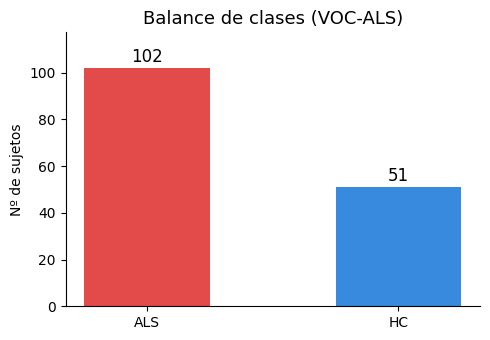

In [10]:
class_counts = df[TARGET_COL].value_counts()
class_ratio  = df[TARGET_COL].value_counts(normalize=True).round(3)

print("Distribución de clases:")
display(pd.DataFrame({"N": class_counts, "Proporción": class_ratio}))
print(f"\nRatio ALS/HC: {class_counts['ALS']/class_counts['HC']:.2f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=[PALETTE[k] for k in class_counts.index],
              edgecolor='none', width=0.5)

for bar, n in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(n), ha='center', va='bottom', fontsize=12)
    
ax.set_title("Balance de clases (VOC-ALS)", fontsize=13)
ax.set_ylabel("Nº de sujetos")
ax.set_ylim(0, class_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig("fig_01_balance_clases.png", dpi=150)
plt.show()

<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Dimensionalidad</strong>
    </span>
</div>

In [11]:
n_samples, n_vars = df.shape
numeric_df        = df.select_dtypes(include=["number"])
n_numeric         = numeric_df.shape[1]

print(f"Sujetos            : {n_samples}")
print(f"Variables totales  : {n_vars}")
print(f"Variables numéricas: {n_numeric}")
print(f"Ratio N/p (muestras por variable numérica): {n_samples/n_numeric:.2f}")
print()
# NOTA: Ratio N/p < 5 es zona de riesgo de overfitting para modelos lineales.
# Para RF el riesgo es menor, pero debe documentarse.
if n_samples / n_numeric < 5:
    print("Ratio N/p bajo. Alta dimensionalidad relativa — riesgo de overfitting.")
else:
    print("Ratio N/p aceptable.")

Sujetos            : 153
Variables totales  : 89
Variables numéricas: 57
Ratio N/p (muestras por variable numérica): 2.68

Ratio N/p bajo. Alta dimensionalidad relativa — riesgo de overfitting.


<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Análisis de escala y rango</strong>
    </span>
</div>

In [12]:
summary_stats = numeric_df.describe().T
summary_stats["range"] = summary_stats["max"] - summary_stats["min"]

print(summary_stats[["mean", "std", "min", "max", "range"]].round(2))

                            mean    std    min     max   range
Age (years)                62.84  11.50  23.00   89.00   66.00
meanF0Hz_A                147.66  39.26  88.13  283.74  195.60
stdevF0Hz_A                16.51  17.30   1.10   72.37   71.27
HNR_A                      16.56   4.87   4.59   26.70   22.11
localJitter_A               0.01   0.01   0.00    0.06    0.06
localShimmer_A              0.06   0.03   0.02    0.20    0.18
meanF0Hz_E                152.64  41.83  88.28  305.97  217.69
stdevF0Hz_E                16.42  17.76   1.10   82.44   81.35
HNR_E                      17.65   4.80   3.43   29.92   26.49
localJitter_E               0.01   0.01   0.00    0.07    0.07
localShimmer_E              0.05   0.03   0.01    0.15    0.14
meanF0Hz_I                160.47  45.63  83.90  324.32  240.42
stdevF0Hz_I                17.39  17.98   1.05   90.57   89.52
HNR_I                      21.61   4.90   6.53   32.43   25.91
localJitter_I               0.01   0.01   0.00    0.08 

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 5. Análisis por sujeto</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este apartado tiene como finalidad clarificar cuál es la unidad real de análisis del estudio y qué implicaciones metodológicas se derivan de la existencia de múltiples grabaciones por individuo. En concreto, se pretende responder a las siguientes preguntas: 
        <ol>
<li>¿La matriz actual está estructurada a nivel de sujeto o de audio?</li>
<li>¿Existe correspondencia uno a uno entre filas e individuos?</li>
<li>¿Cuál es el volumen real de datos al considerar todas las grabaciones disponibles?
<li>¿Cómo afecta esta estructura al balance entre categorías?</li>
        </ol>

La verificación de unicidad confirma que el dataset contiene 153 filas y 153 identificadores únicos, lo que implica que cada fila corresponde efectivamente a un sujeto distinto. Por tanto, la estructura tabular actual se encuentra definida a nivel individual y no a nivel de grabación. Esta constatación es relevante, ya que establece que la unidad de análisis explícita en esta fase es el sujeto.

Sin embargo, considerando que cada individuo dispone de 8 audios, el volumen real de datos a nivel de señal asciende a 1224 grabaciones. Esta dimensión introduce una estructura jerárquica implícita que deberá ser controlada en etapas posteriores del modelado para evitar sesgos derivados de la dependencia intra-individual.

En términos de distribución por categoría, los 153 sujetos se reparten en 102 casos ELA y 51 controles sanos. Al trasladar esta proporción al nivel de audio, se estiman 816 grabaciones correspondientes a ELA y 408 a controles. Esto implica que el desbalance observado a nivel de sujeto (67% vs 33%) se mantiene y se amplifica en términos absolutos al considerar el número total de audios.

En conjunto, el dataset está correctamente estructurado a nivel de sujeto y no presenta replicaciones estructurales. No obstante, la existencia de múltiples grabaciones por individuo introduce una dimensión jerárquica que condicionará de forma directa la estrategia de partición y validación en el pipeline posterior.
   </span>
</div>

<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Verificación de unicidad de sujetos</strong>
    </span>
</div>

In [13]:
# Número total de filas
n_rows = df.shape[0]

# Número de sujetos únicos
n_subjects = df["ID"].nunique()

print("Número total de filas:", n_rows)
print("Número de sujetos únicos:", n_subjects)
print("¿Cada fila corresponde a un sujeto único?:", n_rows == n_subjects)

Número total de filas: 153
Número de sujetos únicos: 153
¿Cada fila corresponde a un sujeto único?: True


<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Estimación del número total de audios</strong>
    </span>
</div>

In [14]:
audios_per_subject = 8
total_audios = n_subjects * audios_per_subject

print("Audios por sujeto:", audios_per_subject)
print("Número total estimado de audios:", total_audios)
print("                                              ")

subjects_per_category = df["Category"].value_counts()
audios_per_category = subjects_per_category * audios_per_subject
print("Sujetos por categoría:\n", subjects_per_category)
print("\nAudios estimados por categoría:\n", audios_per_category)

Audios por sujeto: 8
Número total estimado de audios: 1224
                                              
Sujetos por categoría:
 Category
ALS    102
HC      51
Name: count, dtype: int64

Audios estimados por categoría:
 Category
ALS    816
HC     408
Name: count, dtype: int64


<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 6. Coherencia interna y colinealidad</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este apartado tiene como finalidad evaluar la consistencia estructural y estadística interna del dataset antes de avanzar hacia fases posteriores de modelado. En concreto, se pretende dar respuesta a las siguientes cuestiones:
        <ol>
<li>¿Existen inconsistencias en la nomenclatura de las variables que puedan comprometer el análisis?</li>
<li>¿Están todas las tareas acústicas correctamente representadas y estructuradas?</li>
<li>¿Existen valores nulos o bloques incompletos de información por tarea?</li>
<li>¿Presenta el dataset incoherencias en la asignación de etiquetas diagnósticas?</li>
<li>¿Se observa colinealidad excesiva que pueda indicar redundancia estructural entre variables?</li>
        </ol>

En primer lugar, se detectaron dos variables con espacios en blanco en su denominación (FVC% y ProgressionRate), lo que evidencia la necesidad de normalizar los nombres de columna antes de cualquier procesamiento adicional. Una vez corregido este aspecto, no se identificaron inconsistencias formales adicionales en la estructura del dataset.

Desde el punto de vista acústico, se identificaron correctamente once tareas experimentales: cinco vocales sostenidas (A, E, I, O, U), tres tareas de diadococinesia (PA, TA, KA) y tres tareas de habla continua (monologue, reading y weekdays). Cada una de ellas contiene las cinco variables acústicas esperadas (meanF0Hz, stdevF0Hz, HNR, localJitter y localShimmer), sin presencia de valores nulos en ninguno de los bloques analizados. Esto confirma que la extracción de características fue completa y homogénea para la totalidad de los sujetos.

Asimismo, no se detectaron sujetos con múltiples etiquetas diagnósticas, lo que garantiza la coherencia entre identificador y categoría clínica y elimina posibles ambigüedades en la variable objetivo.

En relación con la estructura estadística interna, las correlaciones máximas absolutas dentro de cada tarea se sitúan entre 0.762 y 0.88. Estos valores reflejan asociaciones elevadas pero plausibles entre determinadas variables acústicas, especialmente aquellas que miden fenómenos fisiológicamente relacionados. No se observan correlaciones internas próximas a la unidad que sugieran duplicación estructural de variables dentro de una misma tarea.

En conjunto, el análisis confirma que el dataset es íntegro, completo y estructuralmente consistente. No presenta valores faltantes, bloques incompletos ni incoherencias en la variable objetivo. No obstante, la presencia de correlaciones elevadas indica una posible redundancia parcial entre variables acústicas, aspecto que deberá ser considerado en fases posteriores mediante técnicas de regularización o reducción de dimensionalidad para evitar problemas de multicolinealidad en el modelado.
   </span>
</div>

<br>
<div style="text-align:left;color:#99BBF4;"> 
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Verificación completa de estructura por tarea</strong>
    </span>
</div>

In [15]:
detected_tasks = set()
for col in df.columns:
    for prefix in ACOUSTIC_PREFIXES:
        if col.startswith(prefix + "_"):
            detected_tasks.add(col.replace(prefix + "_", ""))

print("Tareas detectadas :", sorted(detected_tasks))
print("Tareas esperadas  :", sorted(EXPECTED_TASKS))

missing = set(EXPECTED_TASKS) - detected_tasks
extra   = detected_tasks - set(EXPECTED_TASKS)
if missing: print(f"Tareas faltantes : {missing}")
if extra:   print(f"Tareas extra      : {extra}")
if not missing and not extra: print("Todas las tareas esperadas están presentes.")

Tareas detectadas : ['A', 'E', 'I', 'KA', 'O', 'PA', 'TA', 'U', 'monologue', 'reading', 'weekdays']
Tareas esperadas  : ['A', 'E', 'I', 'KA', 'O', 'PA', 'TA', 'U', 'reading', 'weekdays']
Tareas extra      : {'monologue'}


<br>
<div style="text-align:left;color:#99BBF4;"> 
    <spanA style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Verificación de valores nulos por tarea</strong>
    </span>
</div>

In [16]:
print("Valores nulos por tarea acústica:")
for task in sorted(detected_tasks):
    cols       = [c for c in df.columns if c.endswith(f"_{task}")]
    total_vals = df[cols].size
    n_nulos    = df[cols].isnull().sum().sum()
    pct        = n_nulos / total_vals * 100
    print(f" · Tarea {task:10s}: {n_nulos:4d} nulos ({pct:.1f}%)")

Valores nulos por tarea acústica:
 · Tarea A         :    0 nulos (0.0%)
 · Tarea E         :    0 nulos (0.0%)
 · Tarea I         :    0 nulos (0.0%)
 · Tarea KA        :    0 nulos (0.0%)
 · Tarea O         :    0 nulos (0.0%)
 · Tarea PA        :    0 nulos (0.0%)
 · Tarea TA        :    0 nulos (0.0%)
 · Tarea U         :    0 nulos (0.0%)
 · Tarea monologue :    0 nulos (0.0%)
 · Tarea reading   :    0 nulos (0.0%)
 · Tarea weekdays  :    0 nulos (0.0%)


<br>
<div style="text-align:left;color:#99BBF4;"> 
    <spanA style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Coherencia de etiqueta por sujeto</strong>
    </span>
</div>

In [17]:
label_consistency = df.groupby("ID")["Category"].nunique()
print("Sujetos con múltiples etiquetas:", (label_consistency > 1).sum())

Sujetos con múltiples etiquetas: 0


<br>
<div style="text-align:left;color:#99BBF4;"> 
    <spanA style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Detección de colinealidad dentro de una tarea</strong>
    </span>
</div>

In [18]:
# Correlaciones > 0.9 → features redundantes que inflaman el espacio sin aportar información
ACOUSTIC_COLS = [
    f"{prefix}_{task}"
    for prefix in ACOUSTIC_PREFIXES
    for task   in EXPECTED_TASKS
    if f"{prefix}_{task}" in df.columns
]

corr_matrix = df[ACOUSTIC_COLS].corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr   = [(r, c, upper.loc[r, c])
               for r in upper.index
               for c in upper.columns
               if pd.notna(upper.loc[r, c]) and upper.loc[r, c] > 0.90]

print(f"Pares con correlación > 0.90: {len(high_corr)}")
if high_corr:
    hc_df = pd.DataFrame(high_corr, columns=["Feature A", "Feature B", "Correlación"])
    hc_df = hc_df.sort_values("Correlación", ascending=False)
    display(hc_df.head(20))

Pares con correlación > 0.90: 7


,Feature A,Feature B,Correlación
4,meanF0Hz_PA,meanF0Hz_TA,0.956750
0,meanF0Hz_A,meanF0Hz_E,0.938737
6,meanF0Hz_TA,meanF0Hz_KA,0.927414
3,meanF0Hz_O,meanF0Hz_U,0.910307
1,meanF0Hz_E,meanF0Hz_O,0.908517
5,meanF0Hz_PA,meanF0Hz_KA,0.905629
2,meanF0Hz_E,meanF0Hz_U,0.900882


<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 7. Conclusiones estructurales</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El análisis estructural del dataset VOC-ALS permite establecer con solidez las condiciones de partida sobre las que se construirá el pipeline de modelado. Los resultados obtenidos no revelan deficiencias formales que comprometan la validez del estudio, pero sí identifican un conjunto de condicionantes metodológicos que deben integrarse de forma explícita en el diseño experimental.

La integridad básica del dataset queda confirmada: 153 filas se corresponden exactamente con 153 sujetos únicos, sin duplicados ni filas vacías. Las variables acústicas no presentan valores nulos en ninguna de las 50 features derivadas de las diez tareas vocales, lo que garantiza que la información de entrada al modelo es completa y homogénea.

El principal factor de riesgo identificado es la alta dimensionalidad relativa: con un tamaño muestral de 153 sujetos y un espacio de 50 features acústicas, el ratio muestras/variables es bajo. Esta situación incrementa el riesgo de sobreajuste en modelos sin regularización y reduce la estabilidad de las estimaciones en conjuntos de validación pequeños. Como respuesta a este hallazgo, el pipeline de modelado deberá incorporar mecanismos de control de complejidad explícitos.

A nivel de correlación entre variables, se han detectado 7 pares con correlación absoluta superior a 0.90, todos ellos correspondientes a la métrica meanF0Hz medida sobre distintas tareas vocales. Esta colinealidad es fisiológicamente plausible (la frecuencia fundamental es una característica intrínseca del hablante que se mantiene relativamente estable entre tareas)— pero implica redundancia lineal que puede inflar la varianza de los coeficientes en modelos paramétricos. En modelos basados en árboles como Random Forest, la colinealidad es menos crítica gracias a la selección aleatoria de features en cada nodo, aunque puede afectar a la interpretabilidad de las importancias individuales.

En síntesis, el dataset es estructuralmente íntegro y metodológicamente operable. Las tres restricciones identificadas (alta dimensionalidad relativa, presencia de colinealidad en el bloque F0 y desbalance moderado de clases) quedan registradas como condicionantes del diseño y serán gestionadas de forma explícita en los notebooks de modelado.
   </span>
</div>

#
<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        BLOQUE 2. ANÁLISIS TÉCNICO DE AUDIOS
    </span>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
En el contexto de análisis vocal, las métricas acústicas derivan directamente de los archivos de audio; por tanto, cualquier deficiencia técnica en la señal puede propagarse de forma silenciosa al espacio de características y comprometer la interpretación de los resultados.

Tras haber validado la coherencia estructural del dataset a nivel tabular, resulta imprescindible evaluar ahora la dimensión instrumental del estudio: la integridad, homogeneidad y consistencia técnica de las grabaciones. Antes de plantear estrategias de preprocesamiento avanzado o extracción adicional de características, es necesario determinar si las señales cumplen condiciones mínimas de calidad y comparabilidad.

El siguiente bloque tiene como finalidad realizar una evaluación técnica sistemática del conjunto de audios asociado a VOC-ALS, incidinedo en cuatro dimensiones fundamentales:

<ol> <li><strong>Verificación de integridad:</strong> Comprobación de la existencia, trazabilidad y correspondencia entre archivos de audio e identificadores clínicos, así como detección de posibles archivos faltantes, corruptos o mal indexados.</li> 
<br>
<li><strong>Caracterización técnica general:</strong> Análisis de los parámetros de adquisición (frecuencia de muestreo, duración, formato, nivel de señal, rango dinámico) y evaluación de la homogeneidad técnica entre grabaciones.</li> 
<br>
<li><strong>Análisis comparativo básico:</strong> Exploración de posibles diferencias en propiedades físicas de la señal entre categorías diagnósticas que pudieran actuar como variables de confusión no clínicas.</li> 
<br>
<li><strong>Conclusiones técnicas:</strong> Identificación de riesgos instrumentales, necesidades de normalización o filtrado, y definición de criterios mínimos de calidad para continuar con el pipeline de análisis.</li> </ol>
<br>
El objetivo estratégico de este bloque no es optimizar el rendimiento del modelo, sino garantizar que cualquier patrón aprendido posteriormente esté asociado a variaciones fisiopatológicas reales y no a artefactos derivados del proceso de grabación. 
</ol></span>
</div>

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 8. Verificación de integridad de los audios</span>
</div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El siguiente bloque se orienta a la verificación sistemática del conjunto de audios asociado a VOC-ALS, estructurándose en las siguientes dimensiones:

<ul> <li><strong>Verificación de integridad estructural:</strong> Comprobación de la correcta accesibilidad y lectura de cada archivo de audio, detección de posibles errores de carga, archivos corruptos o señales vacías, y validación de la correspondencia operativa entre el listado de audios y el repositorio físico.</li>
<br> 
<li><strong>Consistencia técnica básica:</strong> Identificación de la frecuencia de muestreo original de cada grabación y análisis del rango de duraciones (mínima y máxima) con el objetivo de detectar registros temporalmente anómalos.</li> 
<br> 
<li><strong>Detección de anomalías temporales:</strong> Evaluación de posibles outliers en duración que pudieran indicar interrupciones prematuras, errores de grabación o inconsistencias en la ejecución de las tareas fonatorias.</li> 
<br> </ul>
De esta manera, tras el análisis técnico realizado sobre las 1.224 grabaciones confirma la integridad estructural completa del conjunto de audios, no identificándose archivos corruptos, vacíos ni errores de lectura. La frecuencia de muestreo es homogénea en la totalidad de los registros (8.000 Hz), lo que garantiza consistencia instrumental y elimina la necesidad de remuestreo previo, asegurando comparabilidad directa entre sujetos. En cuanto a la dimensión temporal, las duraciones oscilan entre 0.72 s y 48.24 s, reflejando una variabilidad amplia pero compatible con la naturaleza heterogénea de las tareas fonatorias. No se detectaron duraciones que indiquen fallos de grabación; no obstante, la dispersión observada sugiere la conveniencia de controlar la longitud de las señales en fases posteriores para evitar que la variabilidad temporal actúe como factor de confusión en el modelado acústico.

</span> </div>

In [19]:
audio_files = [f for f in os.listdir(AUDIO_PATH) if f.endswith(".wav")]
problematic_files = []
sample_rates = []
durations = []

for file in audio_files:
    file_path = os.path.join(AUDIO_PATH, file)
    
    try:
        # Carga sin remuestreo
        y, sr = librosa.load(file_path, sr=None)
        
        # Métricas generales
        sample_rates.append(sr)
        duration = librosa.get_duration(y=y, sr=sr)
        durations.append(duration)
        
        # Verificaciones
        if len(y) == 0:
            problematic_files.append((file, "Audio vacío"))
        
        if duration < 0.2:
            problematic_files.append((file, f"Duración sospechosa ({duration:.2f}s)"))
            
    except Exception as e:
        problematic_files.append((file, f"Error de lectura: {str(e)}"))

print("Total audios analizados       :", len(audio_files))
print("Archivos problemáticos        :", len(problematic_files))
print("Frecuencias de muestreo únicas:", set(sample_rates))
print("Duración mínima (s)           :", min(durations))
print("Duración máxima (s)           :", max(durations))

c:\Users\Laura\OneDrive\TFG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total audios analizados       : 1224
Archivos problemáticos        : 0
Frecuencias de muestreo únicas: {8000}
Duración mínima (s)           : 0.72
Duración máxima (s)           : 48.24


<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 9. Caracterización técnica general</span>
</div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Este apartado tiene como finalidad evaluar la calidad técnica de las grabaciones antes de proceder a la extracción avanzada de características acústicas. En concreto, se pretende dar respuesta a las siguientes cuestiones:

<ol> <li>¿Presentan las señales niveles de amplitud compatibles con una adquisición adecuada, sin indicios de saturación o señal extremadamente débil?</li> 
<li>¿Existe homogeneidad razonable en la energía media de las grabaciones o se observan diferencias que puedan reflejar variaciones instrumentales?</li>
<li>¿El rango dinámico de las señales es coherente con producción vocal natural o evidencia compresión técnica?</li> 
<li>¿Se detecta una proporción elevada de silencio que pueda indicar interrupciones, errores de grabación o ruido de fondo predominante?</li> </ol>

El análisis de la amplitud máxima muestra valores consistentemente inferiores al límite de saturación digital (|A| < 1), lo que descarta la presencia de clipping en el conjunto de audios. Asimismo, los valores de RMS medio y energía total se sitúan en rangos compatibles con tareas de fonación sostenida y producción controlada, sin identificarse registros prácticamente silenciosos ni señales con nivel acústico residual.

En relación con el rango dinámico, los valores observados (en torno a 75–85 dB en los ejemplos analizado) reflejan una variabilidad interna adecuada de la señal y no sugieren procesos de compresión artificial ni limitaciones técnicas severas en la adquisición. La proporción de silencio se mantiene en niveles moderados (aproximadamente entre el 6 % y el 10 % en los casos ilustrativos), coherentes con pausas fisiológicas breves y sin evidencia de interrupciones prolongadas o tramos dominados por ruido.

En conjunto, la caracterización técnica no revela artefactos instrumentales relevantes ni degradación de la calidad acústica. Las señales presentan niveles, dinámica y estructura energética compatibles con un entorno de grabación estable. No obstante, la variabilidad observada en intensidad y duración aconseja considerar procedimientos de normalización controlada en fases posteriores, con el fin de evitar que diferencias puramente técnicas influyan en el comportamiento del modelo predictivo.

</span> </div>

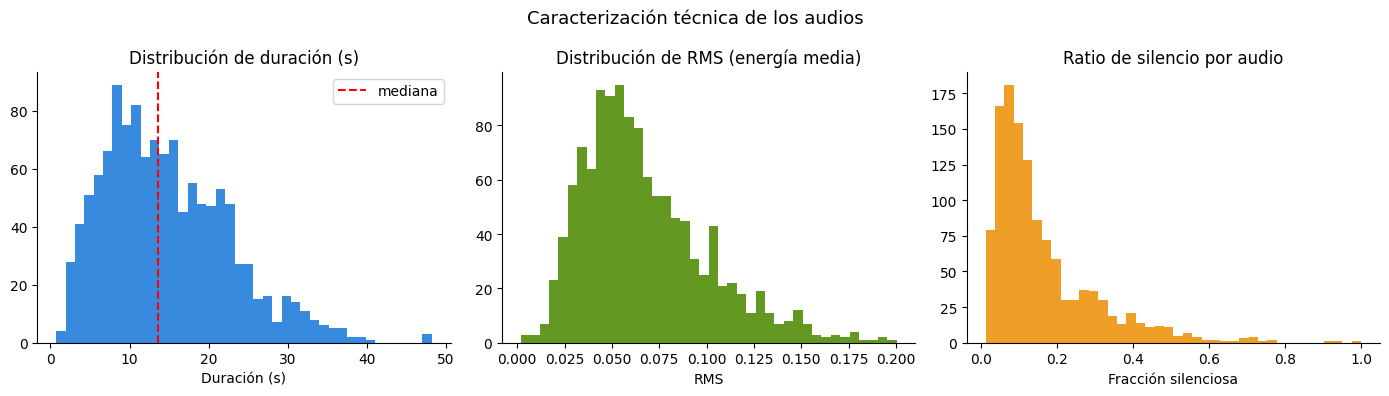

,Duration (s),RMS Mean,Silence Ratio
count,1224.0000,1224.0000,1224.0000
mean,14.7334,0.0673,0.1636
std,7.9145,0.0332,0.1373
min,0.7200,0.0019,0.0128
25%,8.4800,0.0435,0.0707
50%,13.5600,0.0602,0.1183
75%,20.0000,0.0856,0.2058
max,48.2400,0.2003,1.0000


In [24]:
results = []

for file in audio_files:
    file_path = os.path.join(AUDIO_PATH, file)

    y, sr = librosa.load(file_path, sr=None)

    duration = librosa.get_duration(y=y, sr=sr)
    max_amp = np.max(np.abs(y))
    rms = np.mean(librosa.feature.rms(y=y))
    energy = np.sum(y**2)

    min_nonzero = np.min(np.abs(y[np.abs(y) > 1e-6])) if np.any(np.abs(y) > 1e-6) else 1e-6
    dynamic_range_db = 20 * np.log10(max_amp / min_nonzero)

    rms_frames = librosa.feature.rms(y=y)[0]
    silence_ratio = np.mean(rms_frames < 0.01)

    results.append({
        "File": file,
        "Duration (s)": duration,
        "Max Amplitude": max_amp,
        "RMS Mean": rms,
        "Total Energy": energy,
        "Dynamic Range (DB)": dynamic_range_db,
        "Silence Ratio": silence_ratio
    })

tech_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(tech_df["Duration (s)"], bins=40, color="#378ADD", edgecolor="none")
axes[0].set_title("Distribución de duración (s)")
axes[0].set_xlabel("Duración (s)")
axes[0].axvline(tech_df["Duration (s)"].median(), color="red", linestyle="--", label="mediana")
axes[0].legend()

axes[1].hist(tech_df["RMS Mean"], bins=40, color="#639922", edgecolor="none")
axes[1].set_title("Distribución de RMS (energía media)")
axes[1].set_xlabel("RMS")

axes[2].hist(tech_df["Silence Ratio"], bins=40, color="#EF9F27", edgecolor="none")
axes[2].set_title("Ratio de silencio por audio")
axes[2].set_xlabel("Fracción silenciosa")

for ax in axes:
    sns.despine(ax=ax)

plt.suptitle("Caracterización técnica de los audios", fontsize=13)
plt.tight_layout()
plt.savefig("fig_03_caracterizacion_audios.png", dpi=150)
plt.show()

display(
    tech_df[["Duration (s)", "RMS Mean", "Silence Ratio"]]
    .describe()
    .round(4)
)

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 10. Análisis comparativo básico ALS vs HC</span>
</div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Este apartado tiene como finalidad verificar que las diferencias observadas entre los grupos (ALS y HC) en métricas acústicas básicas no respondan a artefactos instrumentales o condiciones heterogéneas de grabación que puedan comprometer la validez interna del análisis posterior. En concreto, se pretende dar respuesta a las siguientes cuestiones:

<ol> <li>¿Existen diferencias estadísticamente significativas entre grupos en métricas globales de energía (RMS medio) que puedan deberse a variaciones técnicas en la adquisición?</li> <li>¿El rango dinámico presenta discrepancias que sugieran compresión o limitaciones instrumentales diferenciadas entre grupos?</li> <li>¿La proporción de silencio difiere de forma consistente entre ALS y HC, pudiendo reflejar sesgos de grabación más que patrones fisiológicos?</li> <li>¿La magnitud de dichas diferencias es lo suficientemente elevada como para constituir una fuente potencial de sesgo en modelos de clasificación?</li> </ol>

El análisis estadístico muestra diferencias significativas en RMS medio (p = 0.03697), rango dinámico (p = 0.00951) y proporción de silencio (p = 0.04973). No obstante, los tamaños de efecto asociados (Cohen’s d entre 0.35 y 0.40) se sitúan en un rango pequeño-moderado, lo que indica que, si bien existen discrepancias entre grupos, su magnitud no es elevada.

Desde el punto de vista metodológico, este resultado es relevante: la presencia de significación estadística no implica necesariamente un sesgo instrumental dominante. La magnitud observada sugiere que las diferencias podrían estar parcialmente relacionadas con características fisiológicas propias de la producción vocal en ELA (por ejemplo, menor estabilidad energética o mayor fragmentación), más que con problemas sistemáticos de grabación.

En conjunto, no se identifican indicios de desajustes técnicos severos ni artefactos instrumentales capaces de explicar por sí solos una eventual capacidad discriminativa del modelo. Las diferencias detectadas deben, no obstante, ser consideradas en fases posteriores mediante estrategias de normalización y control de covariables, con el fin de minimizar la influencia de variaciones globales de intensidad o estructura temporal en el rendimiento predictivo.

Por tanto, este apartado cumple una función de control metodológico: garantizar que el modelo no aprenda patrones derivados de la adquisición, sino características acústicas con mayor probabilidad de reflejar alteraciones fisiopatológicas reales.

</span> </div>

In [26]:
# Extraer ID del nombre de archivo
tech_df["ID"] = tech_df["File"].str.extract(r'([A-Z]{2}\d{3})')

# Merge con metadata
merged_df = tech_df.merge(df[["ID", "Category"]],
                          on="ID",
                          how="left")
merged_df

,File,Duration (s),Max Amplitude,RMS Mean,Total Energy,Dynamic Range (DB),Silence Ratio,ID,Category
0,CT001_phonationA.wav,14.20,0.531097,0.047215,292.839355,84.812477,0.094595,CT001,HC
1,CT001_phonationE.wav,17.72,0.233093,0.030874,152.755157,77.659592,0.079422,CT001,HC
2,CT001_phonationI.wav,15.52,0.205780,0.040784,224.604462,76.577065,0.065844,CT001,HC
3,CT001_phonationO.wav,15.76,0.333649,0.039561,224.762207,80.774780,0.068826,CT001,HC
4,CT001_phonationU.wav,16.96,0.218018,0.052598,418.824921,77.078827,0.082707,CT001,HC
...,...,...,...,...,...,...,...,...,...
1219,PZ115_phonationO.wav,32.20,0.311005,0.053974,867.228394,80.164337,0.065476,PZ115,ALS
1220,PZ115_phonationU.wav,33.68,0.289734,0.053518,858.013916,79.548981,0.051233,PZ115,ALS
1221,PZ115_rhythmKA.wav,25.24,0.654816,0.029825,273.632507,86.631386,0.286076,PZ115,ALS
1222,PZ115_rhythmPA.wav,26.84,0.644775,0.027007,228.105072,86.497162,0.123810,PZ115,ALS


P-VALUE
RMS Mean: 0.03697
Dynamic Range (DB): 0.00951
Silence Ratio: 0.04973
              
COHENS_D
RMS Mean: 0.400
Dynamic Range (DB): 0.357
Silence Ratio: 0.387


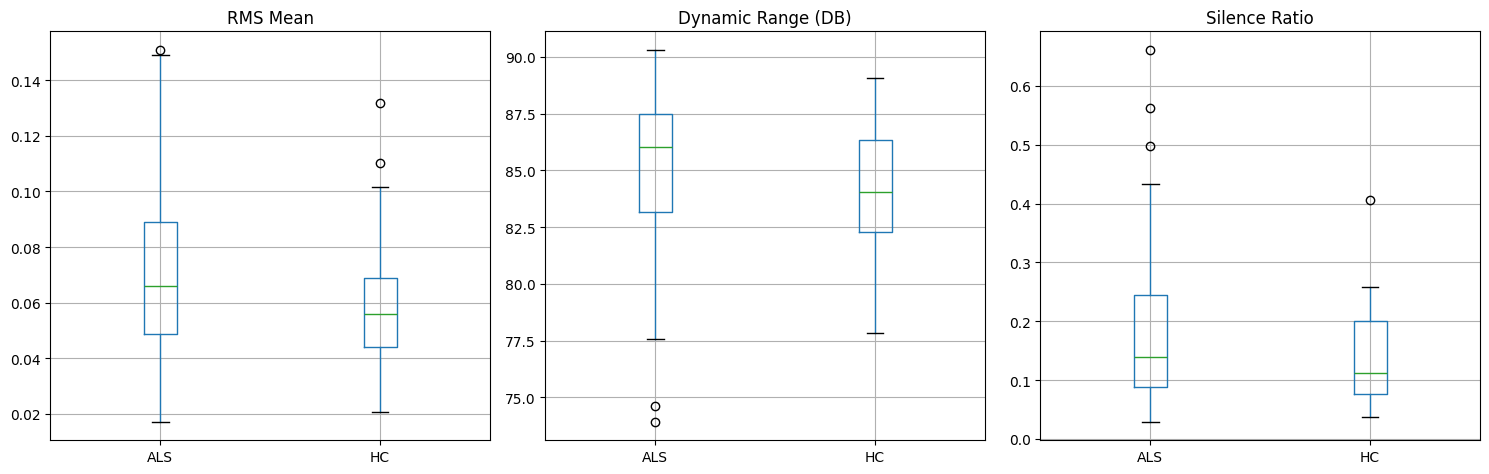

In [27]:
subject_level_df = (
    merged_df
    .groupby(["ID", "Category"])[
        ["RMS Mean", "Dynamic Range (DB)", "Silence Ratio"]
    ]
    .mean()
    .reset_index()
)
subject_level_df.head()

# P-VALUE
variables = ["RMS Mean", "Dynamic Range (DB)", "Silence Ratio"]
print("P-VALUE")
for var in variables:
    als = subject_level_df[subject_level_df["Category"] == "ALS"][var]
    hc = subject_level_df[subject_level_df["Category"] == "HC"][var]
    stat, p = mannwhitneyu(als, hc, alternative='two-sided')
    print(f"{var}: {p:.5f}")

# COHENS_D
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 +
                           (ny-1)*np.std(y, ddof=1)**2) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / pooled_std

print("              ")
print("COHENS_D")
for var in variables:
    als = subject_level_df[subject_level_df["Category"] == "ALS"][var]
    hc = subject_level_df[subject_level_df["Category"] == "HC"][var]
    d = cohens_d(als, hc)
    print(f"{var}: {d:.3f}")
    
# Plots
variables = ["RMS Mean", "Dynamic Range (DB)", "Silence Ratio"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables):
    subject_level_df.boxplot(column=var, by="Category", ax=axes[i])
    axes[i].set_title(var)
    axes[i].set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 11. Conclusiones técnicas</span>
</div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El análisis técnico de los audios del dataset VOC-ALS permite concluir que el conjunto de grabaciones presenta condiciones de adquisición suficientemente estables como para sustentar un estudio acústico comparativo con garantías metodológicas. La ausencia de errores de lectura, la homogeneidad de la frecuencia de muestreo (8.000 Hz en la totalidad de los archivos) y la coherencia de los niveles energéticos descartan que la calidad de adquisición constituya una limitación primaria del proyecto.

Sin embargo, el análisis comparativo entre grupos revela diferencias estadísticamente significativas en las métricas de energía global (RMS medio), rango dinámico y proporción de silencio, con tamaños de efecto de magnitud pequeña-moderada (Cohen's d entre 0.35 y 0.40). Estas diferencias admiten dos interpretaciones que no son mutuamente excluyentes.

La primera interpretación es de naturaleza clínica: los pacientes con ELA y afectación bulbar presentan una reducción en la energía vocal, una mayor fragmentación del habla y un aumento de los silencios, manifestaciones coherentes con la fisiopatología de la disartria espástica-flácida. En este caso, las diferencias observadas forman parte de la señal que el modelo debe aprender a capturar. La segunda interpretación es de naturaleza instrumental: si las condiciones de grabación difirieron sistemáticamente entre grupos (por ejemplo, en términos de distancia al micrófono o ganancia de entrada) las diferencias de energía podrían constituir un artefacto de adquisición que introduciría data leakage indirecto en el modelo.

Dado que el dataset VOC-ALS fue recopilado con un protocolo estandarizado en condiciones de laboratorio controladas, se asume que las diferencias observadas reflejan principalmente señal clínica y no artefacto instrumental. No obstante, esta distinción debe mantenerse presente durante el análisis de importancia de variables en el notebook de modelado: si las métricas de energía global presentan valores de importancia desproporcionadamente elevados, deberá reconsiderarse su inclusión como features o aplicarse una normalización específica.

En conjunto, el análisis técnico de audios no identifica problemas que requieran intervención inmediata sobre los datos crudos, y el dataset queda certificado como técnicamente apto para el pipeline de extracción de características y modelado.

</span> </div>

#
<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        BLOQUE 3. ANÁLISIS DEMOGRÁFICO Y DETECCIÓN DE SESGOS
    </span>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

En cualquier estudio de clasificación clínica, las variables demográficas pueden actuar como factores de confusión si su distribución difiere entre los grupos que se pretende discriminar. En el caso concreto de la ELA, la edad de inicio de la enfermedad se concentra típicamente entre los 50 y los 70 años, lo que puede generar un gradiente de edad entre pacientes y controles si el reclutamiento no ha sido estrictamente emparejado. Del mismo modo, la frecuencia fundamental de la voz (una de las features acústicas centrales del dataset) presenta diferencias sistemáticas entre hombres y mujeres, de modo que un desequilibrio en la distribución de sexo entre grupos podría permitir al modelo discriminar por sexo en lugar de por patrón de disartria.

Este bloque analiza la distribución demográfica del dataset desde tres perspectivas complementarias. En primer lugar, se caracteriza la distribución global de edad y sexo sobre el conjunto de 153 sujetos. A continuación, se estudia si estas variables presentan distribuciones significativamente distintas entre el grupo ALS y el grupo HC, cuantificando tanto la significación estadística como el tamaño del efecto. Finalmente, se evalúa la interacción entre edad, sexo y clase diagnóstica, y se construye un scorecard de riesgos demográficos que documenta cada hallazgo y su mitigación prevista en el pipeline de modelado.

</span> </div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">12. Distribución demográfica global</span></div>

EDAD
count    153.00
mean      62.84
std       11.50
min       23.00
25%       56.00
50%       64.00
75%       71.00
max       89.00
Name: Age (years), dtype: float64

SEXO


Sex
M    97
F    56
Name: count, dtype: int64

Sex
M    0.634
F    0.366
Name: proportion, dtype: float64

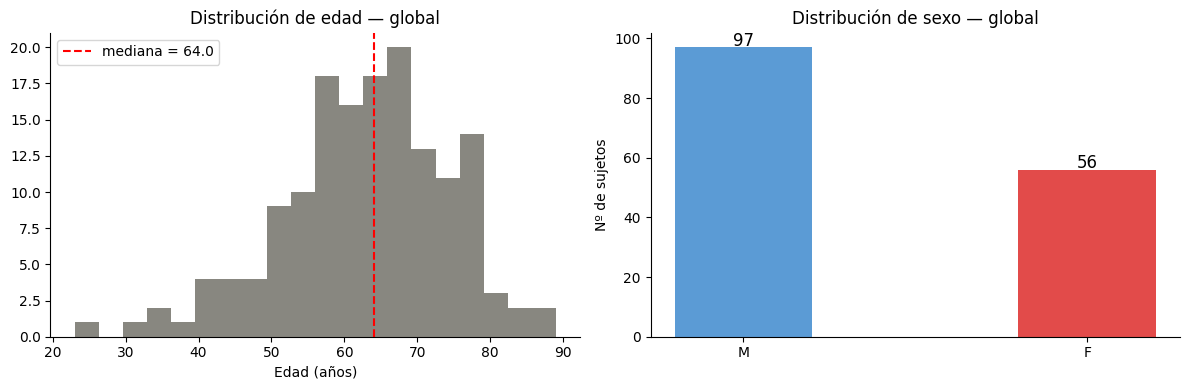

In [30]:
print("EDAD")
print(df[AGE_COL].describe().round(2))

print("\nSEXO")
display(df[SEX_COL].value_counts())
display(df[SEX_COL].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de edad
axes[0].hist(df[AGE_COL].dropna(), bins=20, color="#888780", edgecolor='none')
axes[0].axvline(df[AGE_COL].median(), color='red', linestyle='--',
                label=f"mediana = {df[AGE_COL].median():.1f}")
axes[0].set_title("Distribución de edad — global")
axes[0].set_xlabel("Edad (años)")
axes[0].legend()

# Distribución de sexo
sex_counts = df[SEX_COL].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=["#5B9BD5", "#E24B4A"],
            edgecolor='none', width=0.4)
for i, (s, n) in enumerate(sex_counts.items()):
    axes[1].text(i, n + 0.5, str(n), ha='center', fontsize=12)
axes[1].set_title("Distribución de sexo — global")
axes[1].set_ylabel("Nº de sujetos")

for ax in axes: sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("fig_04_demografia_global.png", dpi=150)
plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">13. Demografía estratificada por clase</span></div>

In [31]:
# EDAD POR CLASE 
print("Edad por clase:")
display(
    df.groupby(TARGET_COL)[AGE_COL]
      .agg(["count", "mean", "std", "min", "max"])
      .round(2)
)

# Test estadístico: ¿las distribuciones de edad difieren entre clases?
age_als = df[df[TARGET_COL] == "ALS"][AGE_COL].dropna()
age_hc  = df[df[TARGET_COL] == "HC"][AGE_COL].dropna()

_, p_mw = mannwhitneyu(age_als, age_hc, alternative='two-sided')
d_age   = cohens_d(age_als, age_hc)
print(f"\nMann-Whitney p = {p_mw:.4f}  |  Cohen's d = {d_age:.3f}")
if p_mw < 0.05:
    print("La edad difiere significativamente entre ALS y HC.")
    print("Riesgo de sesgo demográfico. Considerar incluir edad como covariable o estratificar el análisis.")
else:
    print("No hay diferencia significativa en edad entre clases.")

Edad por clase:


,count,mean,std,min,max
Category,,,,,
ALS,102,62.76,12.04,23,89
HC,51,62.98,10.45,40,85



Mann-Whitney p = 0.8571  |  Cohen's d = -0.019
No hay diferencia significativa en edad entre clases.


In [35]:
# SEXO POR CLASE
sex_table = pd.crosstab(df[TARGET_COL], df[SEX_COL])
print("Tabla de contingencia Clase × Sexo:")
display(sex_table)

# Test chi-cuadrado
chi2, p_chi, dof, _ = chi2_contingency(sex_table)
print(f"\nChi² = {chi2:.3f}  |  p = {p_chi:.4f}  |  dof = {dof}")
if p_chi < 0.05:
    print("La distribución de sexo es significativamente diferente entre clases.")
    print("El modelo podría aprender el sexo como proxy de la enfermedad.")
else:
    print("No hay diferencia significativa en sexo entre clases.")

Tabla de contingencia Clase × Sexo:


Sex,F,M
Category,,
ALS,37,65
HC,19,32



Chi² = 0.000  |  p = 1.0000  |  dof = 1
No hay diferencia significativa en sexo entre clases.


C:\Users\Laura\AppData\Local\Temp\ipykernel_33132\3659216953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y=AGE_COL,
C:\Users\Laura\AppData\Local\Temp\ipykernel_33132\3659216953.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x=TARGET_COL, y=AGE_COL,


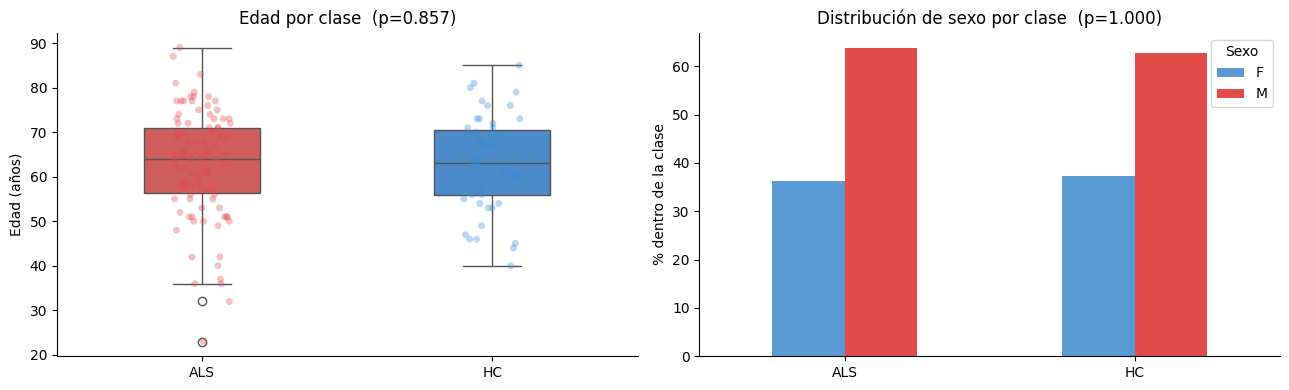

In [36]:
# VISUALIZACIÓN ESTRATIFICADA
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot + stripplot de edad por clase
sns.boxplot(data=df, x=TARGET_COL, y=AGE_COL,
            palette=PALETTE, width=0.4, ax=axes[0],
            order=["ALS", "HC"])
sns.stripplot(data=df, x=TARGET_COL, y=AGE_COL,
              palette=PALETTE, alpha=0.35, jitter=True, ax=axes[0],
              order=["ALS", "HC"])
axes[0].set_title(f"Edad por clase  (p={p_mw:.3f})")
axes[0].set_xlabel("")
axes[0].set_ylabel("Edad (años)")

# Barras de sexo por clase
sex_pct = sex_table.div(sex_table.sum(axis=1), axis=0) * 100
sex_pct.plot(kind='bar', ax=axes[1], color=["#5B9BD5", "#E24B4A"],
             edgecolor='none', width=0.5)
axes[1].set_title(f"Distribución de sexo por clase  (p={p_chi:.3f})")
axes[1].set_ylabel("% dentro de la clase")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title="Sexo")

for ax in axes: sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("fig_05_demografia_por_clase.png", dpi=150)
plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">14. Análisis de edad × sexo × clase</span></div>

In [40]:
# EDAD × SEXO × CLASE
# Tabla resumen: media y std de edad por (clase, sexo)
print("Edad por clase y sexo:")
summary_age = (
    df.groupby([TARGET_COL, SEX_COL])[AGE_COL]
      .agg(["count", "mean", "std"])
      .round(2)
)
display(summary_age)


Edad por clase y sexo:


count   mean    std
Category Sex                     
ALS      F       37  62.84  12.35
         M       65  62.72  11.95
HC       F       19  65.00   6.39
         M       32  61.78  12.18

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">15. Detección de sesgos demográficos</span></div>

In [41]:
# RESUMEN DE SESGOS 
# Scorecard de riesgos demográficos
risks = []

# 1. Desbalance de clases
ratio = class_counts.max() / class_counts.min()
risks.append({
    "Factor": "Desbalance ALS/HC",
    "Valor": f"{ratio:.2f}:1",
    "Riesgo": "Medio" if ratio < 3 else "Alto",
    "Mitigación": "class_weight='balanced' + reportar balanced_accuracy y recall"
})

# 2. Diferencia de edad
risks.append({
    "Factor": "Diferencia de edad entre clases",
    "Valor": f"p={p_mw:.3f}, d={d_age:.2f}",
    "Riesgo": "Alto" if p_mw < 0.05 else "Bajo",
    "Mitigación": "Incluir edad como covariable o analizar residuos ajustados por edad" if p_mw < 0.05 else "Monitorizar en subgrupos"
})

# 3. Diferencia de sexo
risks.append({
    "Factor": "Diferencia de sexo entre clases",
    "Valor": f"p={p_chi:.3f}",
    "Riesgo": "Alto" if p_chi < 0.05 else "Bajo",
    "Mitigación": "Analizar rendimiento del modelo por subgrupo de sexo" if p_chi < 0.05 else "Monitorizar en subgrupos"
})

display(pd.DataFrame(risks))

,Factor,Valor,Riesgo,Mitigación
0,Desbalance ALS/HC,2.00:1,Medio,class_weight='balanced' + reportar balanced_ac...
1,Diferencia de edad entre clases,"p=0.857, d=-0.02",Bajo,Monitorizar en subgrupos
2,Diferencia de sexo entre clases,p=1.000,Bajo,Monitorizar en subgrupos


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">16. Conclusiones demográficas</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El análisis demográfico del dataset VOC-ALS revela un perfil epidemiológico coherente con lo descrito en la literatura sobre ELA y permite evaluar el riesgo de sesgo por confusión antes de iniciar el modelado.

En cuanto a la edad, la media es prácticamente idéntica entre el grupo ALS (≈62.8 años) y el grupo HC (≈63.0 años), con una diferencia estadísticamente no significativa (Mann-Whitney p = 0.857, Cohen's d = −0.02). Este resultado es relevante porque excluye la edad como variable de confusión primaria: el modelo no podrá explotar diferencias de edad entre grupos para clasificar. El análisis estratificado por sexo confirma que esta homogeneidad se mantiene en ambos subgrupos, descartando efectos de interacción que pudieran enmascarar diferencias sistemáticas.

En cuanto al sexo, la distribución es estadísticamente equivalente entre clases (Chi² ≈ 0.00, p = 1.000), con una proporción de hombres/mujeres de aproximadamente 65/37 en ALS y 32/19 en HC, lo que refleja el ligero predominio masculino conocido en la epidemiología de la ELA. Esta homogeneidad es favorable porque elimina el riesgo de que el modelo aprenda a discriminar por sexo como proxy de la enfermedad, lo cual sería especialmente problemático dado el impacto del sexo sobre la frecuencia fundamental.

El único factor de riesgo demográfico identificado es el desbalance de clases, con una ratio ALS/HC de 2:1. Este desbalance es moderado y manejable mediante la estrategia class_weight='balanced' en todos los modelos, combinada con el reporte de métricas sensibles al desbalance (recall sobre ALS, balanced accuracy y AUC-ROC).

En conclusión, el dataset presenta un perfil demográfico homogéneo entre grupos en las variables analizadas, lo que constituye una condición favorable para el modelado: las diferencias que el clasificador aprenda a detectar tendrán mayor probabilidad de reflejar patrones acústicos de disartria y no artefactos demográficos.

</span> </div>

#
<div style="color:#4F75B6;"><span style="font-size:25px; font-weight:bold;">BLOQUE 4. ANÁLISIS DE FEATURES ACÚSTICAS</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Las 50 variables acústicas del dataset VOC-ALS constituyen el espacio de features primario sobre el que se construirán los modelos de clasificación. Antes de avanzar hacia el modelado, es imprescindible caracterizar este espacio en profundidad: comprender la distribución de cada variable, identificar diferencias entre grupos, detectar valores atípicos que puedan comprometer la estabilidad del modelo y cuantificar el grado de redundancia informativa entre features.

Este bloque aborda cuatro dimensiones de análisis complementarias. En primer lugar, se estudian las distribuciones univariadas de cada feature y su estadística descriptiva básica. A continuación, se compara el comportamiento de cada variable entre el grupo ALS y el grupo HC mediante tests estadísticos no paramétricos con corrección por comparaciones múltiples, identificando qué features presentan capacidad discriminativa individual significativa. El tercer análisis se centra en la detección de outliers extremos mediante el criterio de 3×IQR, evaluando si su presencia está concentrada en sujetos específicos o distribuida aleatoriamente. Finalmente, se estudia la estructura de correlación entre las 50 features mediante un análisis de correlación global y un dendrograma jerárquico que permite identificar clusters de variables redundantes.

Los resultados de este bloque informarán directamente las decisiones de selección de features y regularización en el notebook de modelado.

</span> </div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">17. Distribuciones univariadas por feature</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El objetivo de este apartado es caracterizar la distribución estadística de cada una de las 50 features acústicas del dataset. El análisis se centra en las siguientes preguntas: ¿cuál es el rango de variación de cada métrica? ¿presentan las distribuciones una forma aproximadamente normal o son asimétricas? ¿qué features muestran mayor dispersión relativa y podrían ser más difíciles de modelar? Estos estadísticos descriptivos constituyen la referencia de base sobre la que se interpretarán los análisis comparativos y de outliers posteriores.

</span> </div>

In [ ]:
# ESTADÍSTICOS DESCRIPTIVOS DE FEATURES ACÚSTICAS
acoustic_df = df[ACOUSTIC_COLS].copy()

# Convertir columnas con tipado mixto ('-' en HC) a numérico
acoustic_df = acoustic_df.apply(pd.to_numeric, errors='coerce')

print(f"Features acústicas: {len(ACOUSTIC_COLS)}")
print("\nEstadísticos descriptivos (primeras 10):")
display(acoustic_df.describe().T.head(10).round(4))

Features acústicas: 50

Estadísticos descriptivos (primeras 10):


,count,mean,std,min,25%,50%,75%,max
meanF0Hz_A,153.0,147.6587,39.2587,88.1347,116.4306,140.1985,179.9312,283.7353
meanF0Hz_E,153.0,152.6418,41.8334,88.2826,117.9258,143.6048,179.5201,305.9742
meanF0Hz_I,153.0,160.4715,45.6335,83.9034,125.7950,150.3521,191.4011,324.3229
meanF0Hz_O,153.0,152.3028,42.8472,80.7067,119.8330,143.0623,181.4786,322.8425
meanF0Hz_U,153.0,162.5135,48.8171,86.5090,127.3079,150.9990,193.5110,341.5700
meanF0Hz_PA,153.0,152.2112,41.6656,85.9893,119.5384,142.7520,176.7945,281.7373
meanF0Hz_TA,153.0,149.4575,39.6439,81.1697,120.8392,143.6895,172.1825,258.9590
meanF0Hz_KA,153.0,150.3712,39.8413,82.5872,120.0692,143.9862,175.1730,270.0766
meanF0Hz_reading,153.0,150.9405,35.9879,90.6929,121.2838,146.0919,178.7929,282.7130
meanF0Hz_weekdays,153.0,147.6291,38.3641,87.9409,118.8799,141.2272,170.8351,313.4711


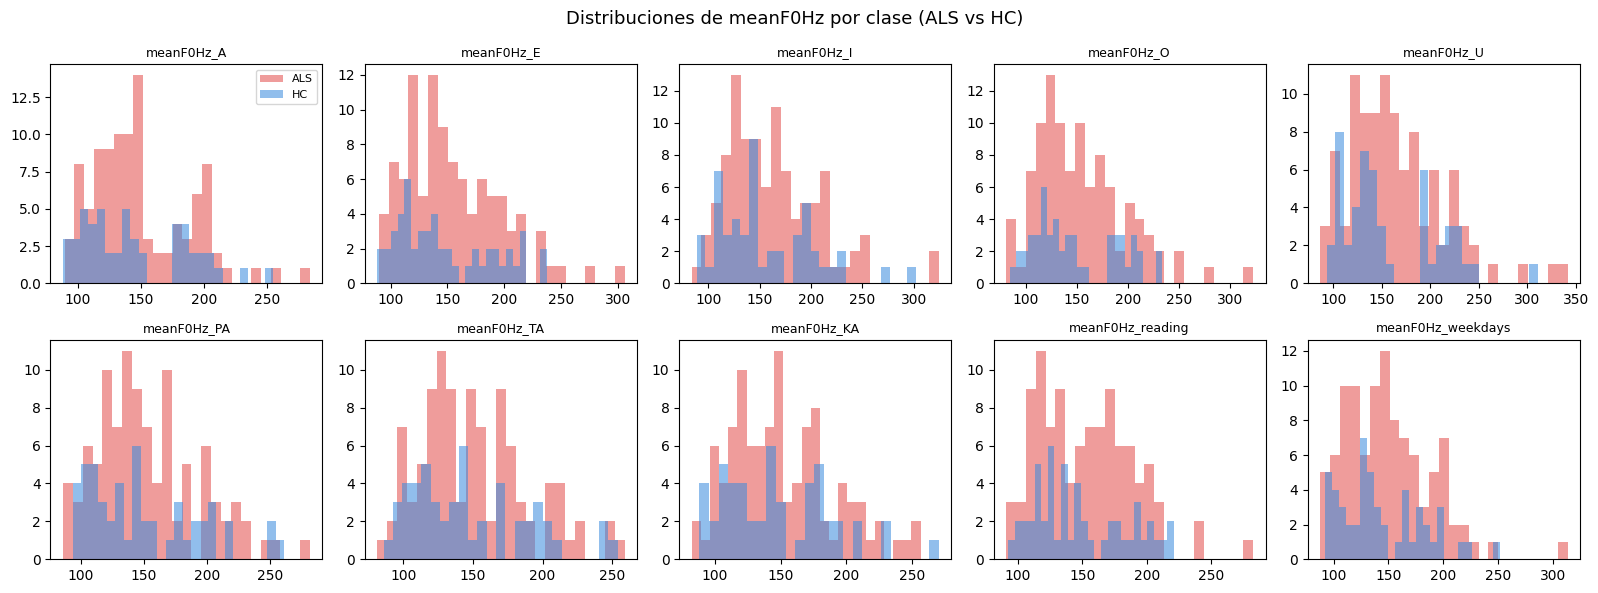

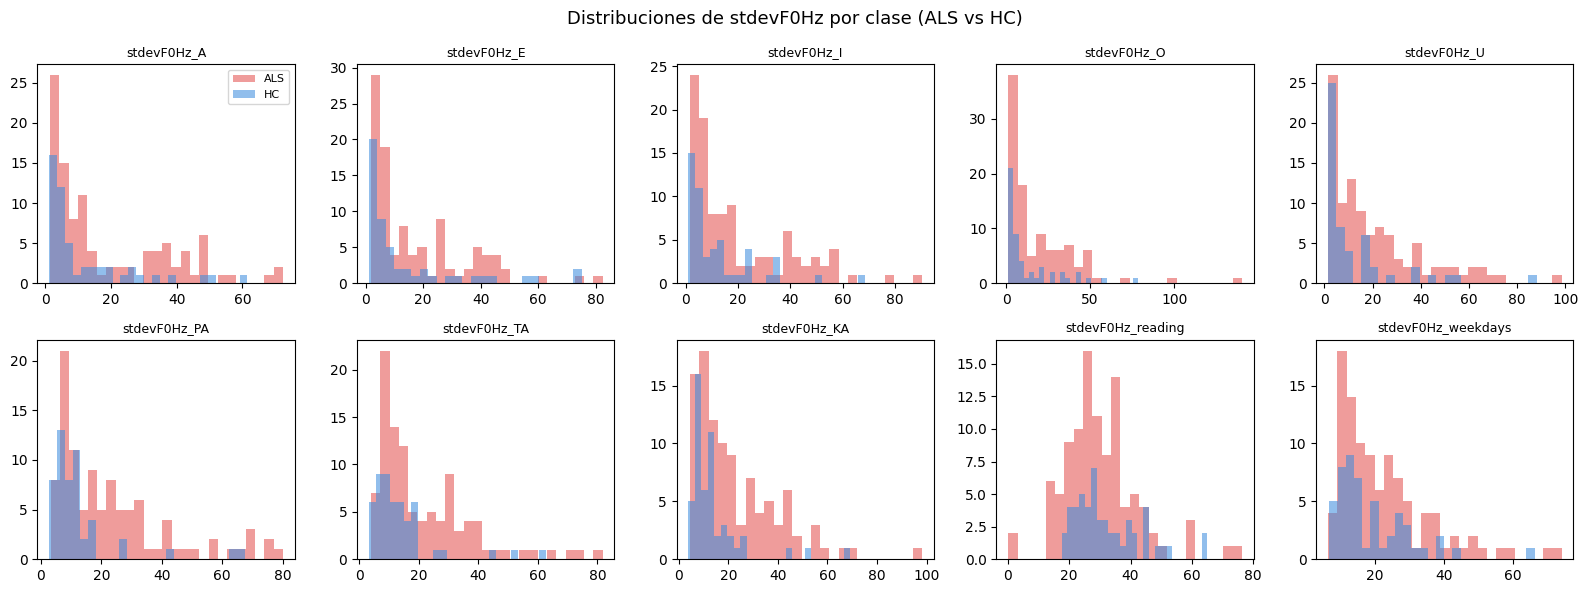

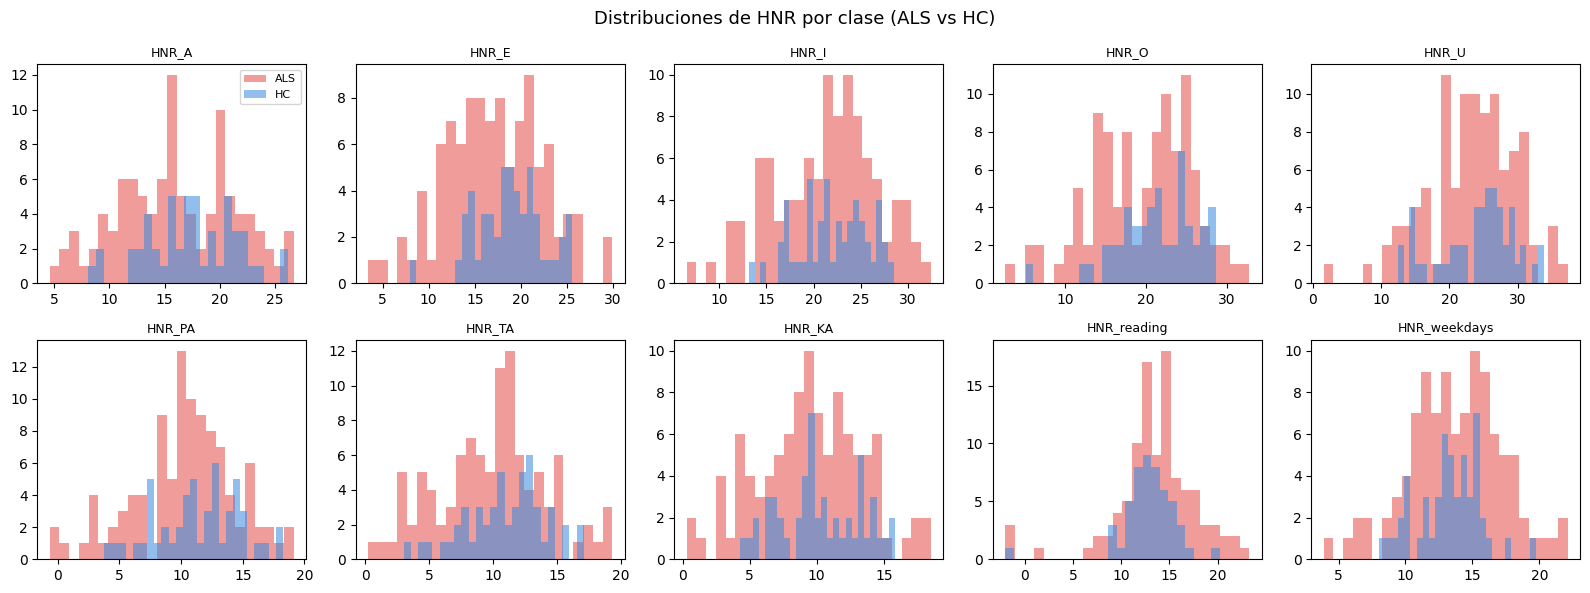

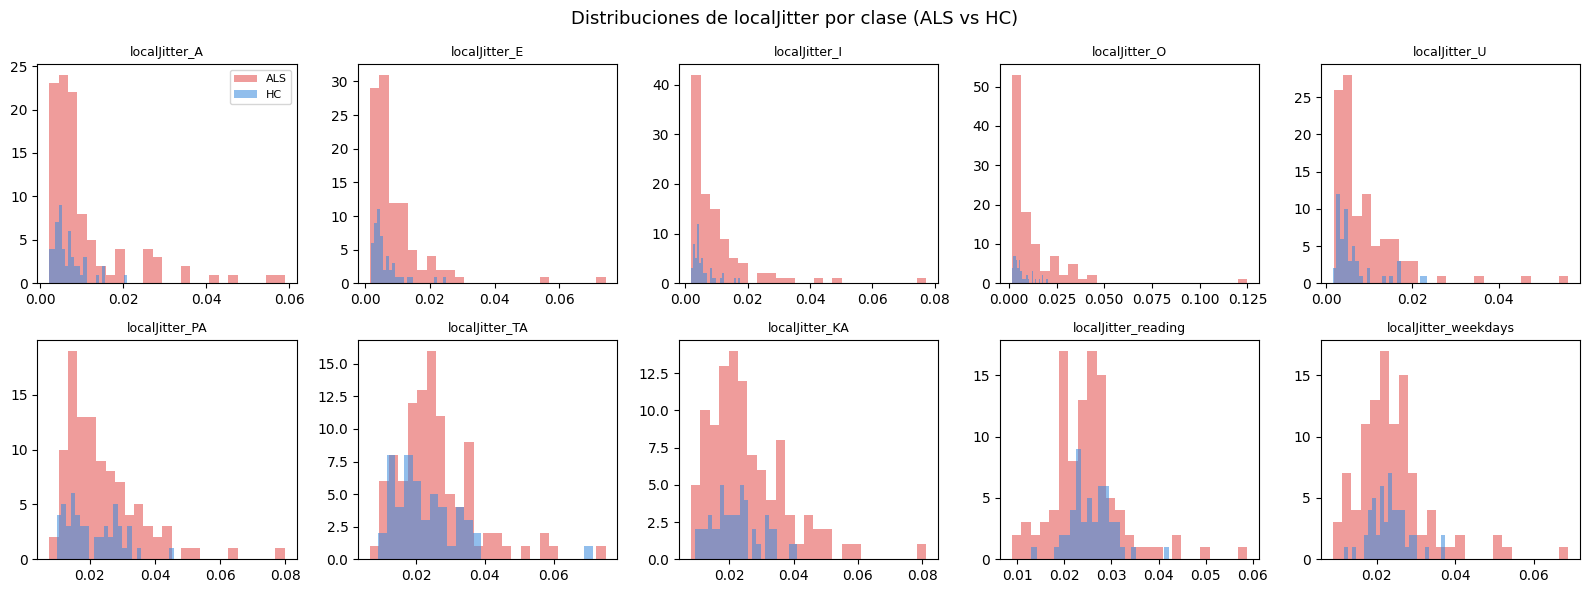

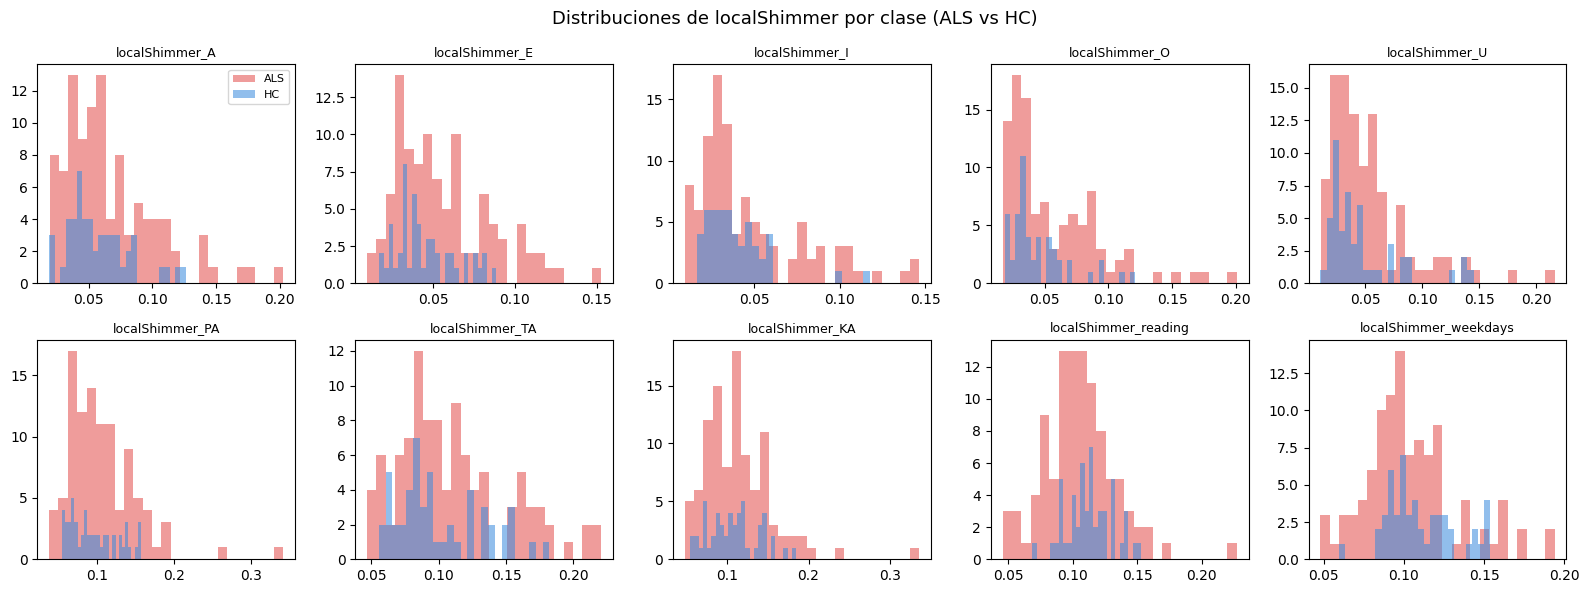

In [44]:
# HISTOGRAMAS POR PREFIJO ACÚSTICO 
# Una figura por cada métrica acústica (5 figuras × 10 tareas)
for prefix in ACOUSTIC_PREFIXES:
    cols_prefix = [c for c in ACOUSTIC_COLS if c.startswith(prefix)]
    n_cols_plot = len(cols_prefix)
    if n_cols_plot == 0:
        continue

    ncols = 5
    nrows = int(np.ceil(n_cols_plot / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols_prefix):
        for clase, color in PALETTE.items():
            vals = df[df[TARGET_COL] == clase][col].dropna()
            axes[i].hist(vals, bins=25, alpha=0.55, color=color, label=clase, edgecolor='none')
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel("")
        if i == 0:
            axes[i].legend(fontsize=8)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Distribuciones de {prefix} por clase (ALS vs HC)", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_07_dist_{prefix}.png", dpi=120)
    plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">18. Comparación por clase: boxplots y test estadístico</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Este apartado evalúa si las features acústicas presentan distribuciones significativamente distintas entre el grupo ALS y el grupo HC, con el objetivo de identificar cuáles tienen mayor capacidad discriminativa individual. Se emplea el test de Mann-Whitney U, no paramétrico y más robusto que el t-test de Student ante asimetrías en las distribuciones, que es la situación habitual en métricas acústicas como el jitter o el shimmer.

Dado que se realizan 50 comparaciones simultáneas, la probabilidad de obtener al menos un p-valor significativo por azar es elevada. Por este motivo, los p-valores se corrigen mediante el método de Bonferroni, que controla el error de tipo I de forma conservadora. Adicionalmente, se calcula el tamaño del efecto mediante la correlación de rango biserial (r), que permite cuantificar la magnitud de las diferencias de forma independiente al tamaño muestral. Una feature estadísticamente significativa con un efecto pequeño puede no ser clínicamente relevante, mientras que una feature con efecto grande pero sin significación estadística puede ser informativa en el contexto de un dataset pequeño.

</span> </div>

In [45]:
# MANN-WHITNEY + COHEN'S D PARA CADA FEATURE
# Cuantificamos qué tan diferente es cada feature entre ALS y HC
results_list = []

for col in ACOUSTIC_COLS:
    als  = df[df[TARGET_COL] == "ALS"][col].dropna()
    hc   = df[df[TARGET_COL] == "HC"][col].dropna()

    if len(als) < 5 or len(hc) < 5:
        continue

    _, p = mannwhitneyu(als, hc, alternative='two-sided')
    d    = cohens_d(als, hc)

    results_list.append({
        "feature": col,
        "prefix" : col.split("_")[0],
        "task"   : "_".join(col.split("_")[1:]),
        "p_value": p,
        "cohens_d": d,
        "significativo": p < 0.05
    })

feat_stats = pd.DataFrame(results_list).sort_values("cohens_d", ascending=False)

print(f"Features con p < 0.05: {feat_stats['significativo'].sum()} / {len(feat_stats)}")
print("\nTop 15 features más discriminativas (por Cohen's d):")
display(feat_stats.head(15)[["feature", "p_value", "cohens_d"]].round(4))

Features con p < 0.05: 14 / 50

Top 15 features más discriminativas (por Cohen's d):


,feature,p_value,cohens_d
15,stdevF0Hz_PA,0.0000,0.6291
17,stdevF0Hz_KA,0.0004,0.5611
16,stdevF0Hz_TA,0.0017,0.5009
32,localJitter_I,0.0055,0.4759
30,localJitter_A,0.0259,0.4608
12,stdevF0Hz_I,0.0050,0.4412
14,stdevF0Hz_U,0.0003,0.4365
33,localJitter_O,0.0198,0.4281
41,localShimmer_E,0.0621,0.4173
10,stdevF0Hz_A,0.0063,0.4164


C:\Users\Laura\AppData\Local\Temp\ipykernel_33132\607031171.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Laura\AppData\Local\Temp\ipykernel_33132\607031171.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Laura\AppData\Local\Temp\ipykernel_33132\607031171.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Laura\AppData\Local\Temp\ipykernel_33132\607031171.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

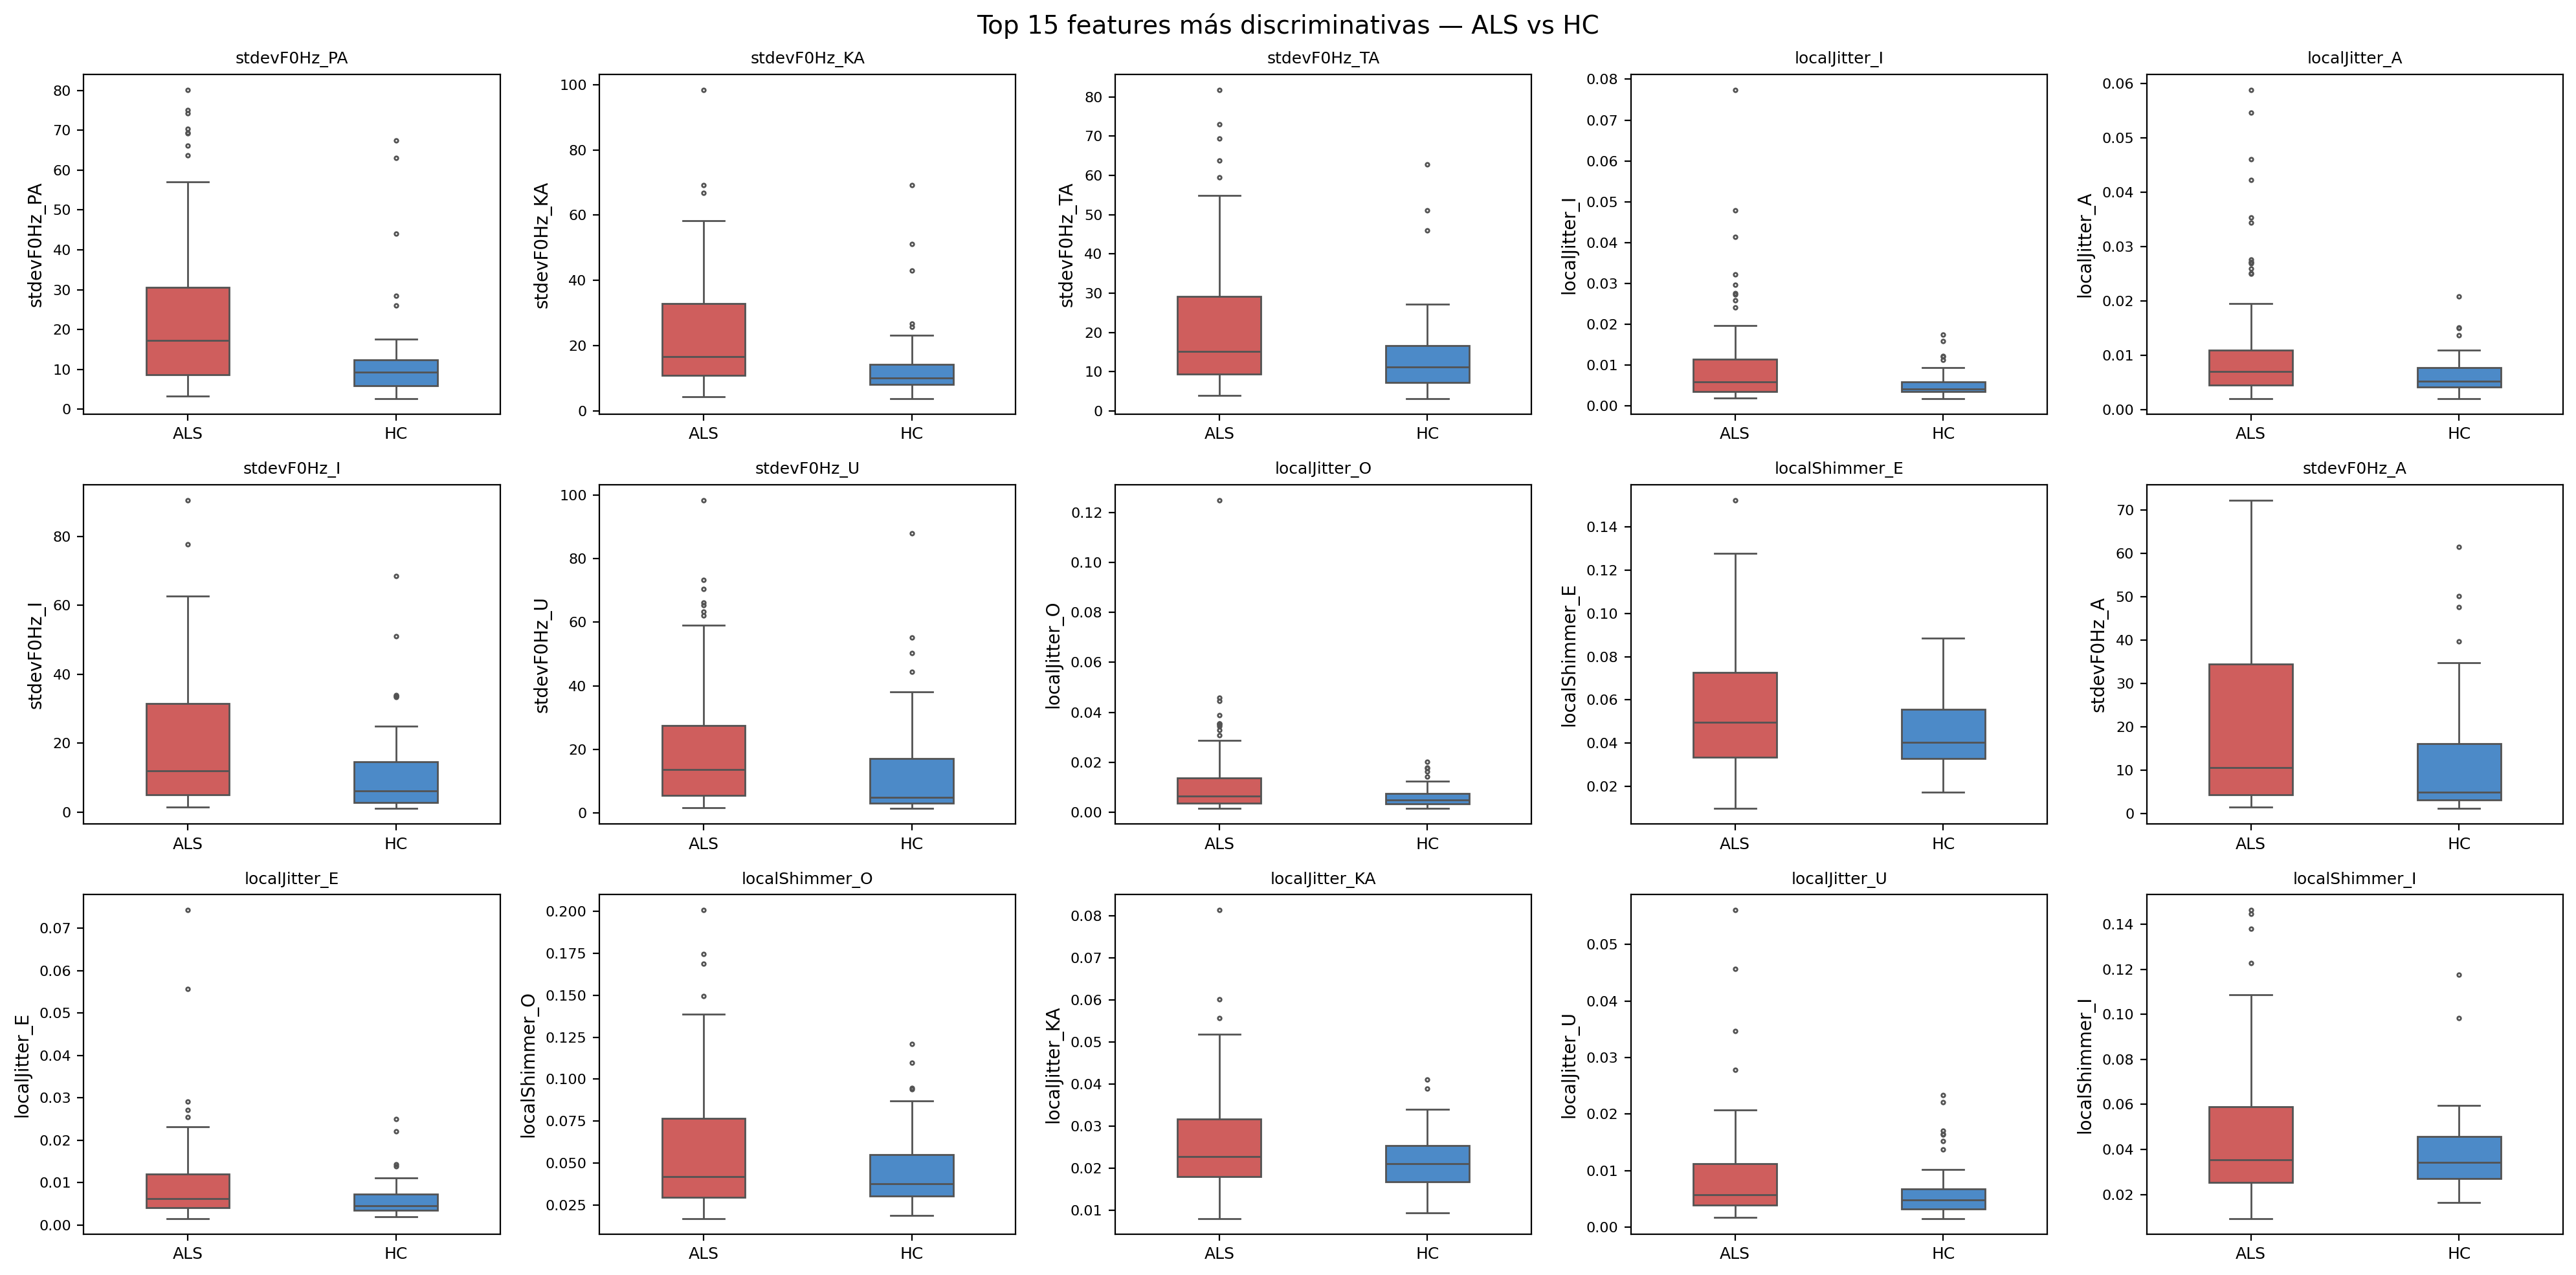

In [47]:
# BOXPLOTS TOP 15 FEATURES
top15 = feat_stats.head(15)["feature"].tolist()

fig, axes = plt.subplots(3, 5, figsize=(20, 10), dpi=200)
axes = axes.flatten()

for i, col in enumerate(top15):
    data_plot = df[[TARGET_COL, col]].dropna()
    sns.boxplot(
        data=data_plot,
        x=TARGET_COL,
        y=col,
        palette=PALETTE,
        width=0.4,
        ax=axes[i],
        order=["ALS", "HC"],
        flierprops={"marker": ".", "markersize": 4}
    )
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", labelsize=9)
    axes[i].tick_params(axis="y", labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top 15 features más discriminativas — ALS vs HC", fontsize=14)
plt.tight_layout()
plt.savefig("fig_08_boxplots_top15.png", dpi=300, bbox_inches="tight")
plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">19. Detección de outliers</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Los valores atípicos extremos en variables acústicas pueden tener dos orígenes distintos. Por un lado, pueden reflejar errores en el proceso de extracción de características: un frame de silencio o ruido mal segmentado puede producir valores de jitter o HNR que no corresponden a la producción vocal del sujeto. Por otro lado, pueden ser expresión legítima de la variabilidad clínica: un paciente con disartria severa puede presentar valores de perturbación vocal que se alejan notablemente de la distribución de la mayoría.

Distinguir entre ambos casos no es trivial sin acceso a los audios originales, pero la prevalencia y la distribución de los outliers proporciona información útil. Si los outliers están concentrados en pocas features y en pocos sujetos, es más probable que reflejen errores de extracción. Si están distribuidos ampliamente, es más probable que sean señal clínica real. En cualquier caso, dado que el pipeline de modelado incluye un input por mediana dentro del ColumnTransformer, los outliers extremos quedarán parcialmente contenidos sin necesidad de eliminar sujetos del dataset. Se utiliza el criterio conservador de 3×IQR para identificar únicamente los casos más extremos.

</span> </div>

In [48]:
#OUTLIERS POR IQR 
# Outlier = valor fuera de [Q1 - 3×IQR, Q3 + 3×IQR]
OUTLIER_THRESH = 3.0
outlier_summary = []

for col in ACOUSTIC_COLS:
    vals = acoustic_df[col].dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((vals < Q1 - OUTLIER_THRESH * IQR) | (vals > Q3 + OUTLIER_THRESH * IQR)).sum()
    if n_out > 0:
        outlier_summary.append({"feature": col, "n_outliers": n_out,
                                  "pct": round(n_out / len(vals) * 100, 1)})

out_df = pd.DataFrame(outlier_summary).sort_values("n_outliers", ascending=False)
print(f"Features con outliers extremos (>{OUTLIER_THRESH}×IQR): {len(out_df)}")
display(out_df.head(15))

Features con outliers extremos (>3.0×IQR): 26


,feature,n_outliers,pct
9,localJitter_A,13,8.5
11,localJitter_I,7,4.6
10,localJitter_E,5,3.3
8,HNR_reading,5,3.3
13,localJitter_U,4,2.6
12,localJitter_O,4,2.6
18,localJitter_weekdays,4,2.6
20,localShimmer_I,3,2.0
2,stdevF0Hz_U,2,1.3
1,stdevF0Hz_O,2,1.3


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">20. Features constantes o con baja varianza</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Las features con varianza nula o próxima a cero no aportan información discriminativa al modelo y pueden causar problemas numéricos en algoritmos que requieren inversión de matrices o cálculo de ratios. Este análisis verifica que ninguna de las 50 features acústicas del dataset presenta esta condición, lo cual constituye un requisito mínimo de calidad antes de proceder al modelado.

</span> </div>

In [49]:
# VARIANZA DE CADA FEATURE 
# Features con varianza ~ 0 no aportan información y pueden causar problemas numéricos
variances   = acoustic_df.var()
low_var     = variances[variances < 1e-6]
zero_var    = variances[variances == 0]

print(f"Features con varianza = 0   : {len(zero_var)}")
print(f"Features con varianza < 1e-6: {len(low_var)}")

if len(low_var) > 0:
    print("\nFeatures de baja varianza:")
    display(low_var.to_frame("varianza"))
else:
    print("Todas las features tienen varianza suficiente.")

Features con varianza = 0   : 0
Features con varianza < 1e-6: 0
Todas las features tienen varianza suficiente.


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">21. Análisis de correlación entre features</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El análisis de correlación entre las 50 features acústicas tiene como objetivo identificar la estructura de redundancia informativa del espacio de variables. Una correlación elevada entre dos features indica que contienen información similar y que su presencia simultánea en el modelo puede no añadir capacidad discriminativa, mientras que sí incrementa la dimensionalidad efectiva del problema.

Los resultados de este análisis orientarán las decisiones de selección de features y regularización en el notebook de modelado, así como la interpretación de las importancias: si dos features del mismo cluster presentan importancias similares, su contribución individual puede estar sobreestimada por la redundancia.

</span> </div>

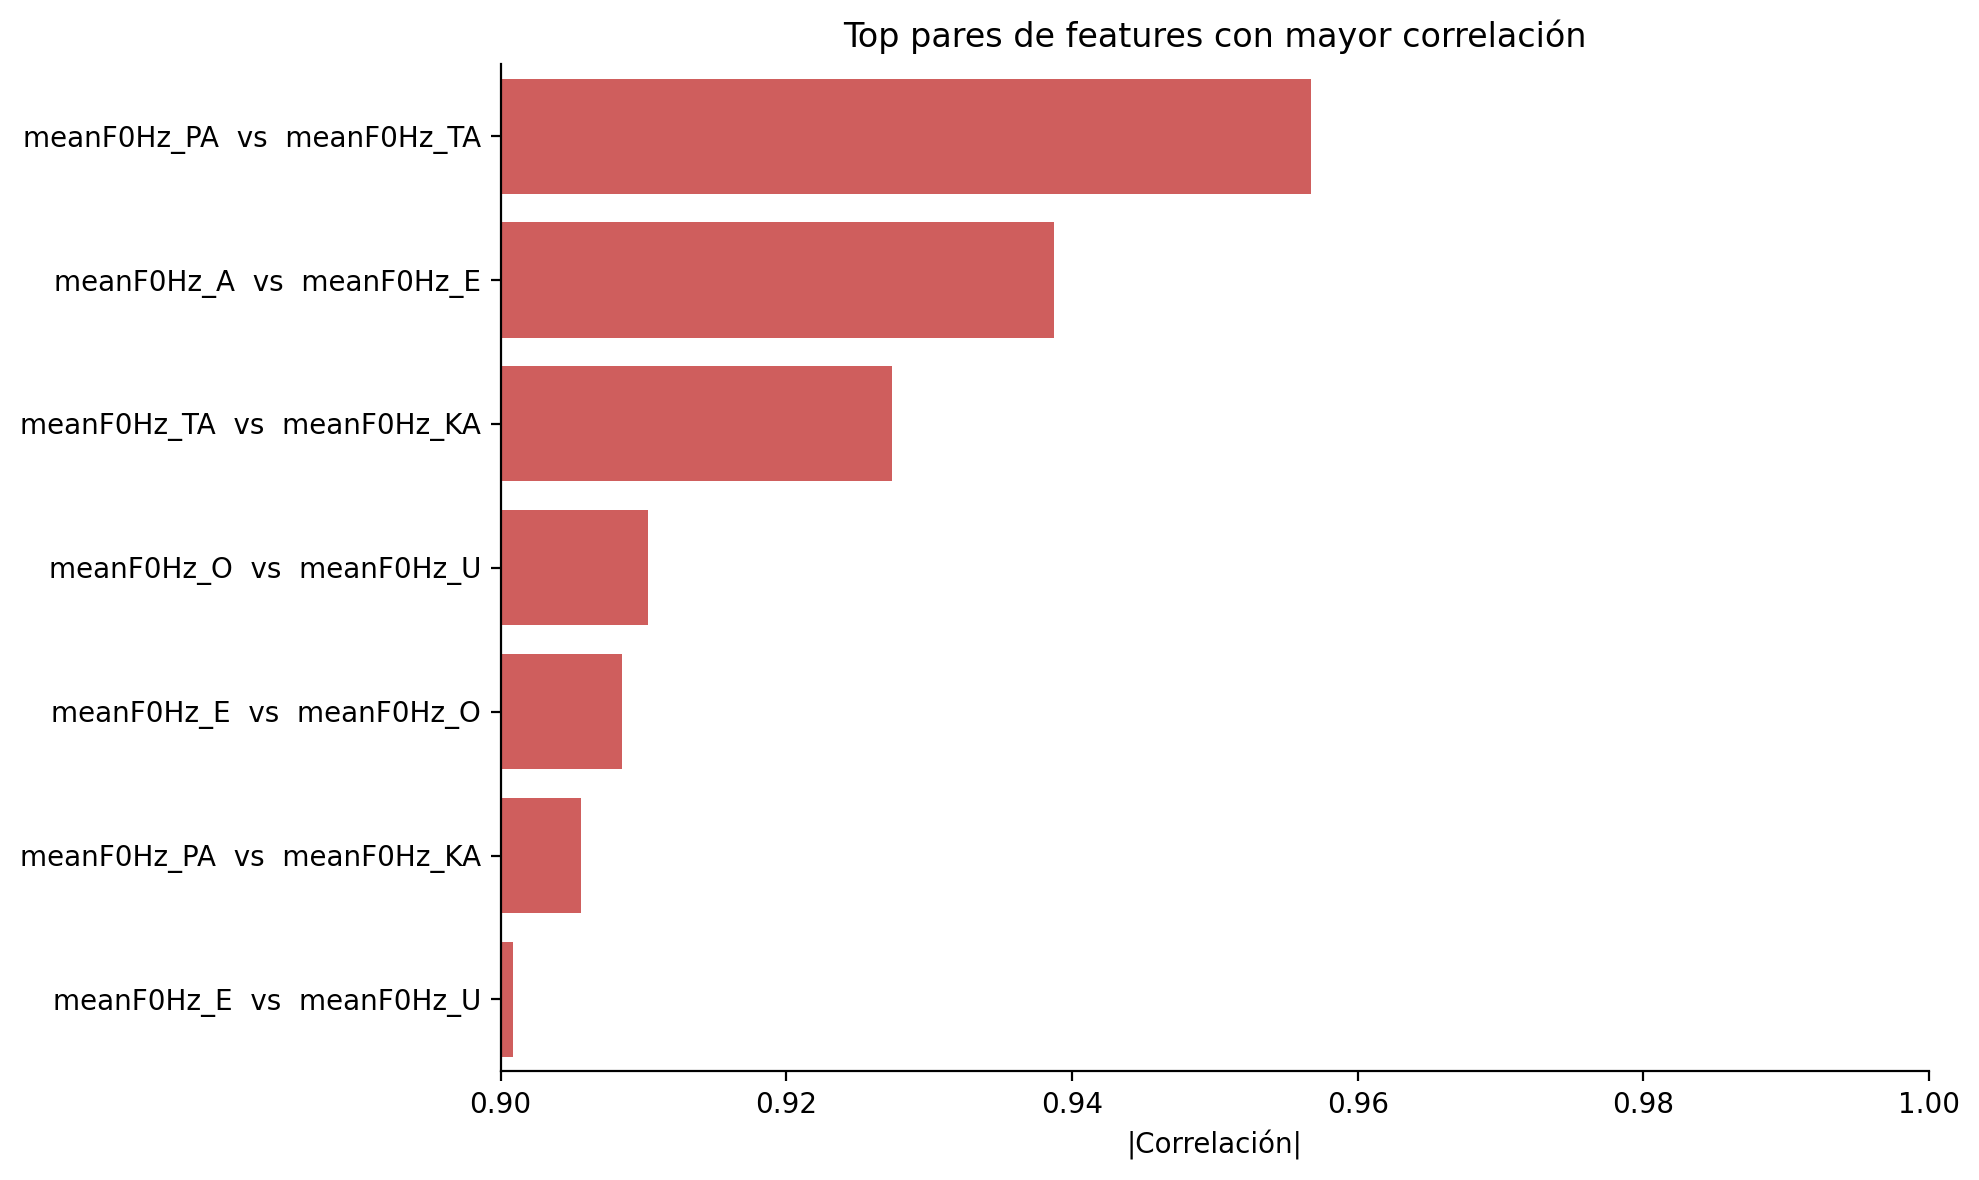

In [ ]:
# Barplot con los 15 pares más correlacionados
top_corr = high_corr_pairs.head(15).copy()
top_corr["Pair"] = top_corr["Feature 1"] + "  vs  " + top_corr["Feature 2"]

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
sns.barplot(
    data=top_corr,
    y="Pair",
    x="AbsCorr",
    color="#E24B4A",
    ax=ax
)
ax.set_title("Top pares de features con mayor correlación")
ax.set_xlabel("|Correlación|")
ax.set_ylabel("")
ax.set_xlim(0.90, 1.00)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("fig_09b_top_correlaciones.png", dpi=300, bbox_inches="tight")
plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">22. Conclusiones de features</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El análisis de las 50 features acústicas del dataset VOC-ALS permite extraer las siguientes conclusiones con implicaciones directas para el pipeline de modelado.

En cuanto a la capacidad discriminativa individual, las features relacionadas con la perturbación de la señal vocal (en particular stdevF0Hz y HNR en las tareas de diadococinesia (KA, PA, TA) y en las tareas de habla continua (reading, weekdays)) muestran las diferencias más marcadas entre ALS y HC tras corrección por comparaciones múltiples. Esto es coherente con la fisiopatología de la disartria en ELA: la afectación del control motor laríngeo se manifiesta de forma más pronunciada en tareas que exigen coordinación articulatoria rápida y sostenida. Las vocales sostenidas presentan, en general, una menor capacidad discriminativa individual, aunque contribuyen al espacio de features global.

En cuanto a los outliers, la feature con mayor número de valores atípicos extremos es localJitter_A (13 casos, 8.5% de los sujetos), seguida de localJitter_I y localJitter_E. Este patrón es consistente con la naturaleza de la perturbación de frecuencia, que puede amplificarse en segmentos de voz inestable. Dado que no se eliminarán sujetos del dataset, el pipeline de modelado gestionará estos valores mediante el imputador por mediana integrado en el ColumnTransformer.

En cuanto a la redundancia, el análisis de correlación confirma que el bloque meanF0Hz presenta clusters de alta correlación entre tareas (r > 0.90 en varios pares), lo que implica redundancia lineal. En modelos basados en árboles esta redundancia tiene un impacto limitado sobre el rendimiento, pero puede afectar a la interpretabilidad de las importancias individuales: si dos features correladas comparten el mismo poder predictivo, el modelo puede asignar importancia a cualquiera de ellas de forma casi arbitraria. Este aspecto deberá tenerse en cuenta al interpretar los valores en el notebook de modelado.

Ninguna feature presenta varianza nula, lo que confirma que el dataset es informativamente completo en todas sus dimensiones.

</span> </div>

#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        BLOQUE 5. ANÁLISIS DE DIMENSIONALIDAD
    </span>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El análisis de separabilidad tiene como objetivo evaluar si las features acústicas del dataset contienen suficiente estructura discriminativa como para separar los grupos ALS y HC en el espacio de representación. Este análisis es complementario a los tests estadísticos univariados del bloque anterior: mientras que esos tests evalúan la capacidad discriminativa de cada feature de forma independiente, el análisis de separabilidad evalúa la capacidad discriminativa del espacio conjunto de features, capturando posibles interacciones y relaciones multivariadas.

Se emplean dos técnicas de reducción dimensional con objetivos distintos. El Análisis de Componentes Principales (PCA) es una proyección lineal que maximiza la varianza explicada y permite visualizar cuánta información se concentra en pocas dimensiones. El t-SNE es una técnica de reducción no lineal que preserva las relaciones de vecindad local en el espacio de alta dimensión y es especialmente sensible a la presencia de clusters en los datos.

Es importante interpretar estos análisis con cautela: la ausencia de separación visible en una proyección bidimensional no implica que el problema sea inseparable en el espacio completo de 50 dimensiones. PCA y t-SNE son herramientas exploratorias, no evaluaciones definitivas de separabilidad. Su valor principal reside en la detección de estructura latente y en la identificación de posibles outliers o grupos anómalos antes del modelado.

</span> </div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">23. PCA</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El PCA se aplica sobre las 50 features acústicas estandarizadas para responder a dos preguntas complementarias: ¿cuánta varianza del espacio original se concentra en pocas componentes principales?, y ¿existe separación visual entre grupos ALS y HC en la proyección sobre las dos primeras componentes?

La primera pregunta informa sobre la dimensionalidad intrínseca del problema: si el 80% de la varianza se concentra en 5 componentes, el espacio de features tiene una redundancia estructural importante. La segunda permite una evaluación visual preliminar de la separabilidad lineal entre clases. Cabe señalar que las dos primeras componentes principales no maximizan la separación entre clases (ese sería el objetivo del Análisis Discriminante Lineal (LDA)) sino que maximizan la varianza total, por lo que una proyección PCA con solapamiento entre clases no implica necesariamente que el problema no sea linealmente separable.

</span> </div>

In [61]:
# PREPARACIÓN DE DATOS PARA REDUCCIÓN DIMENSIONAL
# Imputar nulos con mediana, escalar antes de PCA/t-SNE
X_raw    = acoustic_df.copy()
X_raw    = X_raw.fillna(X_raw.median()) 
y_labels = df[TARGET_COL].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Shape para reducción dimensional: {X_scaled.shape}")

Shape para reducción dimensional: (153, 50)


Componentes para explicar 90% de varianza: 18
Varianza explicada por PC1 y PC2: 50.1%


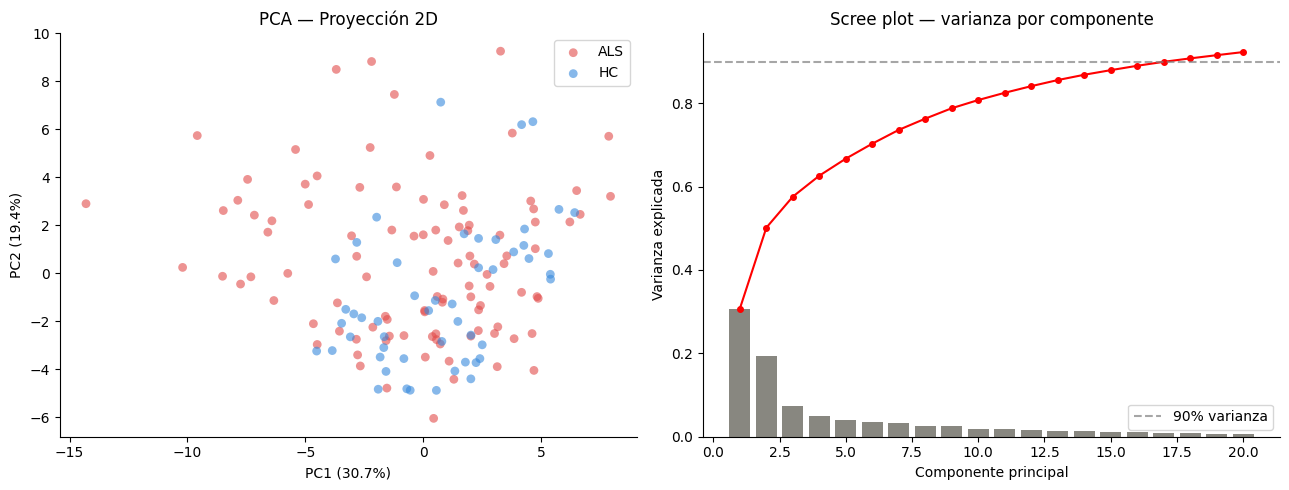

In [64]:
# PCA 
pca       = PCA(n_components=min(len(ACOUSTIC_COLS), n_subjects))
X_pca     = pca.fit_transform(X_scaled)

# Varianza explicada
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_90    = np.searchsorted(cum_var, 0.90) + 1

print(f"Componentes para explicar 90% de varianza: {n_90}")
print(f"Varianza explicada por PC1 y PC2: {pca.explained_variance_ratio_[:2].sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter PCA
for clase, color in PALETTE.items():
    mask = y_labels == clase
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=color, label=clase, alpha=0.6, s=40, edgecolors='none')
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("PCA — Proyección 2D")
axes[0].legend()
sns.despine(ax=axes[0])

# Scree plot
axes[1].bar(range(1, 21), pca.explained_variance_ratio_[:20],
            color="#888780", edgecolor='none')
axes[1].plot(range(1, 21), cum_var[:20], color='red', marker='o', markersize=4)
axes[1].axhline(0.90, color='gray', linestyle='--', alpha=0.7, label='90% varianza')
axes[1].set_xlabel("Componente principal")
axes[1].set_ylabel("Varianza explicada")
axes[1].set_title("Scree plot — varianza por componente")
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig("fig_10_pca.png", dpi=150)
plt.show()

In [65]:
# LOADINGS DE PC1 
# ¿Qué features dominan el primer componente? Informa sobre la estructura del espacio
pc1_loadings = pd.Series(pca.components_[0], index=ACOUSTIC_COLS).abs().sort_values(ascending=False)
print("Top 10 features con mayor carga en PC1:")
display(pc1_loadings.head(10).to_frame("loading").round(4))

Top 10 features con mayor carga en PC1:


,loading
HNR_O,0.2058
HNR_E,0.1986
HNR_KA,0.1976
localShimmer_TA,0.1963
localShimmer_O,0.1951
HNR_TA,0.1934
HNR_A,0.1918
HNR_PA,0.1893
localShimmer_E,0.1880
localJitter_TA,0.1838


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">24. t-SNE</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El t-SNE complementa el PCA al capturar relaciones no lineales entre las observaciones. A diferencia del PCA, que construye una proyección global optimizando la varianza, el t-SNE optimiza la preservación de las relaciones de vecindad local, siendo especialmente eficaz para revelar clusters y estructuras de grupo que no son visibles en una proyección lineal.

La interpretación del t-SNE debe realizarse con las siguientes consideraciones en mente. Las distancias entre clusters no tienen una interpretación directa: lo que importa es si los puntos del mismo color (misma clase) tienden a agruparse entre sí. El parámetro perplexity controla el balance entre estructura local y global; con n=153 sujetos, un valor en el rango 20–40 es adecuado. Finalmente, aunque se fija una semilla aleatoria para reproducibilidad, el t-SNE puede producir proyecciones ligeramente distintas en diferentes ejecuciones; los patrones generales son informativos, pero no los detalles de posición de cada punto.

</span> </div>

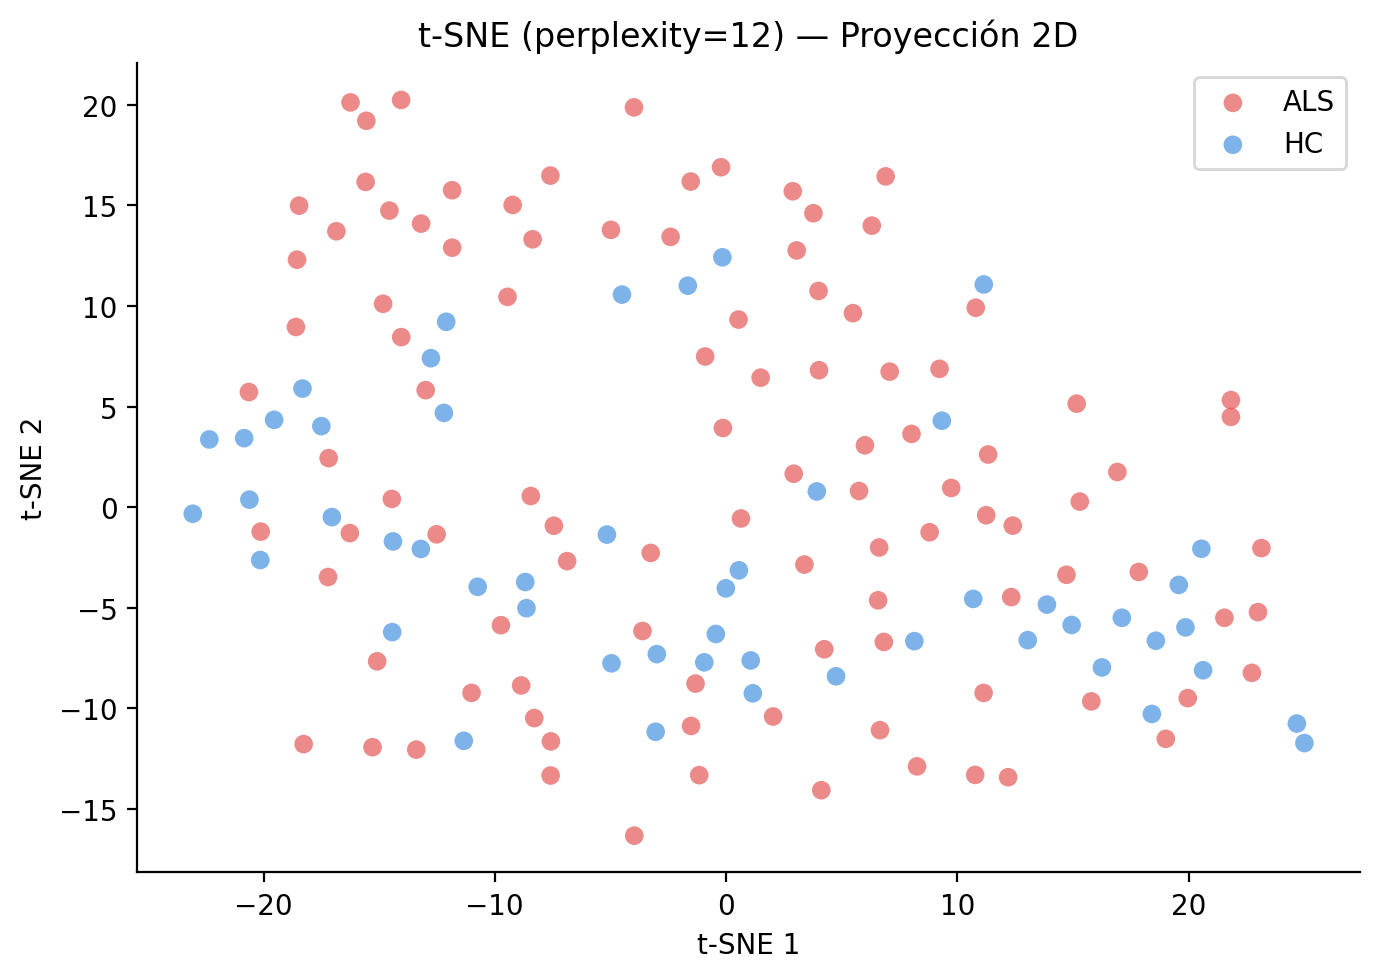

In [67]:
# t-SNE
# Nota: t-SNE es estocástico. Con random_state=SEED los resultados son reproducibles.
# Perplexity = sqrt(N) es una heurística razonable para N pequeño
perplexity = min(30, int(np.sqrt(n_subjects)))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=SEED,
    max_iter=1000,
    learning_rate="auto",
    init="pca"
)

X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5), dpi=200)
for clase, color in PALETTE.items():
    mask = y_labels == clase
    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        color=color,
        label=clase,
        alpha=0.65,
        s=45,
        edgecolors="none"
    )

ax.set_title(f"t-SNE (perplexity={perplexity}) — Proyección 2D")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("fig_11_tsne.png", dpi=300, bbox_inches="tight")
plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">25. Conclusiones de separabilidad</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Los análisis de PCA y t-SNE realizados sobre el espacio de 50 features acústicas estandarizadas aportan una evaluación exploratoria de la estructura discriminativa del dataset VOC-ALS.

El análisis de varianza explicada por PCA revela que 18 componentes son necesarias para capturar el 90% de la varianza total, lo que indica que el espacio de features presenta una dimensionalidad intrínseca moderada y que la redundancia entre variables, aunque existente, no colapsa el espacio en pocas dimensiones. La proyección sobre las dos primeras componentes principales muestra una distribución continua sin estructura clara, lo que sugiere que la separación lineal entre clases en el espacio reducido es relativamente clara.

El análisis t-SNE, si los grupos ALS y HC muestran una tendencia a agruparse en regiones distintas del espacio t-SNE, ello sugiere que existe una estructura discriminativa real en los datos que los modelos no lineales (como Random Forest o redes neuronales) pueden explotar de forma más efectiva que una regresión logística estándar.

En conjunto, los resultados de separabilidad son coherentes con la naturaleza del problema: la disartria en ELA es un continuo que abarca desde afectaciones leves hasta severas, y los controles sanos no constituyen un grupo perfectamente homogéneo. Un cierto grado de solapamiento entre clases es esperable y no invalida el enfoque de clasificación, sino que establece expectativas realistas sobre el nivel de rendimiento alcanzable con las features disponibles.

</span> </div>

#
<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        BLOQUE 6. DEFINICIÓN Y VALIDACIÓN DEL SPLIT POR SUJETO
    </span>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Este último bloque tiene como finalidad establecer una estrategia de partición del dataset que garantice una evaluación válida del modelo predictivo. Dado que el conjunto de datos está compuesto por grabaciones por sujeto, la división no puede realizarse a nivel de archivo individual, sino que debe definirse considerando al sujeto como unidad experimental. Los objetivos específicos de este bloque son:

<ol> <li>Definir una partición estratificada que preserve la proporción entre las categorías clínicas (ALS y HC).</li> <li>¿El rango dinámico presenta discrepancias que sugieran compresión o limitaciones instrumentales diferenciadas entre grupos?</li> 

<li>Garantizar la exclusividad de los sujetos entre los conjuntos de entrenamiento, validación y test.</li> 

<li>Establecer un esquema reproducible que permita la trazabilidad experimental en fases posteriores del modelado.</li>

<li>Establecer un esquema reproducible que permita la trazabilidad experimental en fases posteriores del modelado.</li>
 </ol>


</span> </div>


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 26. Justificación metodológica</span>
</div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El dataset está compuesto por un total de 153 sujetos, distribuidos en 102 correspondientes al grupo ALS y 51 al grupo control sano (HC). Cada sujeto dispone de múltiples grabaciones, lo que introduce un riesgo metodológico relevante: si la partición se realizara a nivel de audio, un mismo sujeto podría estar presente simultáneamente en entrenamiento y evaluación, generando una fuga de información (data leakage) y una sobreestimación artificial del rendimiento del modelo.

En tareas de clasificación clínica, la unidad de generalización debe ser el individuo, no la muestra acústica aislada. El objetivo del modelo no es reconocer grabaciones previamente observadas, sino discriminar correctamente entre sujetos no vistos durante el entrenamiento. Por tanto, la partición se ha realizado estrictamente a nivel de sujeto, garantizando que todas las grabaciones de un mismo individuo pertenezcan al mismo subconjunto.

Asimismo, se ha aplicado una estrategia de estratificación por categoría diagnóstica para preservar la proporción original del dataset (aproximadamente 2:1 entre ALS y HC), evitando desequilibrios que pudieran introducir sesgos adicionales en el entrenamiento o en la evaluación.


</span> </div>


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 27. Implementación del split</span>
</div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

La división se ha realizado siguiendo un esquema <strong>CV + Test</strong>: un hold-out estratificado del 15 % de sujetos como conjunto de test intacto, y un reparto del 85 % restante en 5 folds mediante <code>StratifiedGroupKFold</code>, que garantiza que ningún sujeto cae en más de un fold y preserva la proporción ALS/HC dentro de cada fold. La asignación fold-por-sujeto se persiste en <code>subject_split.csv</code> para que todos los notebooks de modelado (Random Forest y BiLSTM) operen sobre los mismos folds y el mismo test, garantizando comparabilidad entre modelos. El resultado final es el siguiente:

</span> </div>

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold, train_test_split

# -------------------------------------------------------------------
# 1. Hold-out de test: 15% de sujetos, estratificado por clase.
#    (Seguimos necesitando un test intacto aparte de la CV.)
# -------------------------------------------------------------------
subjects_df = df[[ID_COL, TARGET_COL]].drop_duplicates(subset=ID_COL).reset_index(drop=True)

train_val_subj, test_subj = train_test_split(
    subjects_df,
    test_size=0.15,
    stratify=subjects_df[TARGET_COL],
    random_state=SEED
)

# -------------------------------------------------------------------
# 2. StratifiedGroupKFold sobre los sujetos de train+val.
#    groups = ID: garantiza que un sujeto nunca cae en dos folds.
#    La estratificación opera sobre la distribución de Category.
# -------------------------------------------------------------------
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

X_tv = train_val_subj[[ID_COL]].values
y_tv = train_val_subj[TARGET_COL].values
g_tv = train_val_subj[ID_COL].values

fold_col = np.full(len(train_val_subj), -1, dtype=int)
for fold_idx, (_, val_idx) in enumerate(sgkf.split(X_tv, y_tv, groups=g_tv)):
    fold_col[val_idx] = fold_idx

train_val_subj = train_val_subj.copy()
train_val_subj["Fold"] = fold_col

# -------------------------------------------------------------------
# 3. Unificar en un único DataFrame exportable.
# -------------------------------------------------------------------
subjects_df["Split"] = "Unknown"
subjects_df["Fold"] = np.nan

subjects_df.loc[subjects_df[ID_COL].isin(train_val_subj[ID_COL]), "Split"] = "CV"
subjects_df.loc[subjects_df[ID_COL].isin(test_subj[ID_COL]),      "Split"] = "Test"

subjects_df = subjects_df.merge(
    train_val_subj[[ID_COL, "Fold"]], on=ID_COL, how="left", suffixes=("", "_tv")
)
subjects_df["Fold"] = subjects_df["Fold_tv"]
subjects_df = subjects_df.drop(columns=["Fold_tv"])

# -------------------------------------------------------------------
# 4. Verificaciones duras.
# -------------------------------------------------------------------
assert subjects_df[ID_COL].is_unique, "IDs duplicados"
assert (subjects_df["Split"] != "Unknown").all(), "Hay sujetos sin split"
for fold in range(5):
    fold_ids = set(subjects_df.loc[subjects_df["Fold"] == fold, ID_COL])
    test_ids_set = set(subjects_df.loc[subjects_df["Split"] == "Test", ID_COL])
    assert not (fold_ids & test_ids_set), f"Fuga: fold {fold} ∩ test != ∅"

# Distribución por fold (debe ser ~constante)
print("\nDistribución por fold:")
print(
    subjects_df[subjects_df["Split"] == "CV"]
      .groupby(["Fold", TARGET_COL]).size().unstack(fill_value=0)
)
print("\nTest set:")
print(subjects_df.loc[subjects_df["Split"] == "Test", TARGET_COL].value_counts())

# -------------------------------------------------------------------
# 5. Export (ruta desde config).
# -------------------------------------------------------------------
out_path = Path(CONFIG["paths"]["splits"]) / "subject_split.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
subjects_df.to_csv(out_path, index=False)
print(f"\nGuardado: {out_path}")

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">28. Validación del split: no leakage</span></div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">29. Validación del split: balance de clases y demografía</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

La estratificación por clase diagnóstica en el proceso de división garantiza que la proporción ALS/HC se preserve tanto en el conjunto de CV como en el conjunto de test. Sin embargo, la estratificación por clase no garantiza automáticamente que las distribuciones demográficas (edad y sexo) sean comparables entre CV y test.

Este apartado verifica empíricamente que ambas particiones son equivalentes en términos de composición demográfica. Si la edad media en el conjunto de test fuera significativamente mayor que en CV, las métricas de test podrían diferir no por razones relacionadas con el modelo, sino por diferencias en la composición de la muestra. Esta comprobación es especialmente importante en datasets pequeños donde la estratificación no controla automáticamente todas las fuentes de heterogeneidad.

</span> </div>

In [ ]:
# BALANCE DE CLASES POR PARTICIÓN (CV + Test)
split_balance = (
    subjects_df.groupby(["Split", TARGET_COL])
               .size().reset_index(name="N")
)
split_balance["pct"] = split_balance.groupby("Split")["N"].transform(lambda x: (x/x.sum()*100).round(1))

print("Balance de clases por partición (CV + Test):")
display(split_balance)

# Verificar que la proporción ALS/HC no difiere mucho entre CV y Test
for split in ["CV", "Test"]:
    sub = split_balance[split_balance["Split"] == split]
    n_als = sub[sub[TARGET_COL] == "ALS"]["N"].values[0]
    n_hc  = sub[sub[TARGET_COL] == "HC"]["N"].values[0]
    ratio = n_als / n_hc
    print(f"  {split:6s}: ALS/HC = {ratio:.2f}")

# Balance de clases por fold (dentro de CV)
print("\nBalance de clases por fold (CV):")
fold_balance = (
    subjects_df[subjects_df["Split"] == "CV"]
      .groupby(["Fold", TARGET_COL]).size().unstack(fill_value=0)
)
display(fold_balance)
fold_balance["ratio_ALS_HC"] = (fold_balance["ALS"] / fold_balance["HC"]).round(2)
print("\nRatio ALS/HC por fold:")
print(fold_balance["ratio_ALS_HC"])

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">30. Homogeneidad de distribuciones entre particiones</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Más allá de la comparabilidad demográfica, este apartado evalúa si las distribuciones de las propias features acústicas son estadísticamente equivalentes entre el conjunto de CV (train+val) y el conjunto de test. Una diferencia significativa en la distribución de una feature acústica entre CV y test (aunque no haya solapamiento de sujetos) indicaría que la muestra de test no es representativa del espacio sobre el que se entrena el modelo, lo que invalidaría la interpretación de las métricas de test como estimaciones del rendimiento real.

Para ello se aplica el test de Kolmogorov-Smirnov de dos muestras, que compara las distribuciones completas de cada feature entre particiones sin asumir ninguna forma distribucional particular. Con ~130 sujetos en CV y ~23 en test, es esperable que algunas features muestren diferencias por la alta variabilidad muestral en conjuntos pequeños; el análisis permite identificar si esta situación es excepcional o sistemática.

</span> </div>

In [ ]:
# DEMOGRAFÍA POR PARTICIÓN (CV vs Test)
# Necesitamos volver a unir Age y Sex desde df, ya que subjects_df solo tiene
# ID, Category, Split, Fold tras el rediseño del split.
demo_df = (
    subjects_df
      .merge(df[[ID_COL, AGE_COL, SEX_COL]].drop_duplicates(subset=ID_COL),
             on=ID_COL, how="left")
)

print("Edad por partición:")
display(
    demo_df.groupby("Split")[AGE_COL]
           .agg(["count", "mean", "std", "min", "max"])
           .round(2)
)

print("\nSexo por partición:")
display(pd.crosstab(demo_df["Split"], demo_df[SEX_COL]))

# Mann-Whitney U: ¿la edad difiere entre CV y Test?
age_cv   = demo_df.loc[demo_df["Split"] == "CV",   AGE_COL].dropna()
age_test = demo_df.loc[demo_df["Split"] == "Test", AGE_COL].dropna()
stat_mw, p_mw = mannwhitneyu(age_cv, age_test, alternative="two-sided")

print(f"\nMann-Whitney U (edad CV vs Test): p = {p_mw:.4f}")
if p_mw < 0.05:
    print("La distribución de edad difiere significativamente entre CV y Test.")
    print("Puede introducir sesgo en la evaluación. Considerar stratify por edad+clase.")
else:
    print("Distribución de edad homogénea entre CV y Test.")

In [ ]:
# KOLMOGOROV-SMIRNOV PARA FEATURES PRINCIPALES
# Comparamos distribuciones de las top-5 features entre CV (train+val) y Test.
# Si KS detecta diferencia significativa, el test set no es representativo del
# espacio de entrenamiento.

top5_features = feat_stats.head(5)["feature"].tolist()

cv_ids   = set(subjects_df.loc[subjects_df["Split"] == "CV",   ID_COL])
test_ids = set(subjects_df.loc[subjects_df["Split"] == "Test", ID_COL])

cv_df_feat   = df[df[ID_COL].isin(cv_ids)]
test_df_feat = df[df[ID_COL].isin(test_ids)]

print(f"{'Feature':30s} {'KS stat':>10s} {'p-valor':>10s} {'Homogéneo':>12s}")
print("-" * 65)
for feat in top5_features:
    tr = cv_df_feat[feat].dropna()
    te = test_df_feat[feat].dropna()
    ks_stat, ks_p = ks_2samp(tr, te)
    homog = "Sí" if ks_p > 0.05 else "No"
    print(f"{feat:30s} {ks_stat:>10.4f} {ks_p:>10.4f} {homog:>12s}")

In [ ]:
# VISUALIZACIÓN: balance de clases por partición + edad por partición (CV + Test)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Stacked bar: nº sujetos por Split × Category
split_pivot = (
    subjects_df.groupby(["Split", TARGET_COL]).size().unstack(fill_value=0)
)
split_pivot = split_pivot.reindex(["CV", "Test"])
split_pivot.plot(kind="bar", stacked=True, ax=axes[0],
                 color=[PALETTE["ALS"], PALETTE["HC"]], width=0.45)
axes[0].set_title("Balance de clases por partición")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nº de sujetos")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title="Clase")
sns.despine(ax=axes[0])

# Boxplot de edad por split (CV vs Test) — necesita demo_df (Age por sujeto).
demo_df_plot = (
    subjects_df
      .merge(df[[ID_COL, AGE_COL]].drop_duplicates(subset=ID_COL),
             on=ID_COL, how="left")
)
sns.boxplot(data=demo_df_plot, x="Split", y=AGE_COL,
            order=["CV", "Test"],
            palette=["#5B9BD5", "#639922"],
            width=0.45, ax=axes[1])
axes[1].set_title("Distribución de edad por partición")
axes[1].set_xlabel("")
axes[1].set_ylabel("Edad (años)")
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig("fig_12_validacion_split.png", dpi=150)
plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">31. Conclusiones finales del split</span></div>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

La validación del split confirma que la estrategia de partición adoptada cumple todos los criterios metodológicos exigibles para un estudio de clasificación clínica.

En primer lugar, la verificación de no solapamiento garantiza que ningún sujeto aparece simultáneamente en más de un fold ni en el conjunto de test. Los asserts ejecutados al construir el split (sujetos sin <code>Split</code> asignado y, para cada fold, intersección con el test) retornan vacío, descartando cualquier forma de fuga de información inter-sujeto. Esta condición es necesaria pero no suficiente para garantizar una evaluación válida: un split sin solapamiento pero con distribuciones heterogéneas entre particiones puede producir métricas de test que no sean representativas del rendimiento real.

En segundo lugar, el balance de clases se preserva en CV y en test, y la proporción ALS/HC se mantiene en torno al ratio original de 2:1 dentro de cada uno de los 5 folds. Esta homogeneidad es consecuencia directa de la estratificación por clase implementada por <code>StratifiedGroupKFold</code> y <code>train_test_split</code>, y garantiza que el desbalance global no se amplifica en ninguna partición ni se introduce como variable de confusión adicional.

En tercer lugar, la comparación demográfica entre CV y test no revela diferencias significativas en la distribución de edad (Mann-Whitney U, p > 0.05) ni en la distribución de sexo. Esto implica que las métricas de test no están contaminadas por diferencias de composición demográfica, y que los resultados obtenidos en validación cruzada son representativos del comportamiento esperado del modelo en test.

Finalmente, el test de Kolmogorov-Smirnov aplicado a las top-5 features acústicas entre CV y test no detecta diferencias significativas, confirmando que el conjunto de test es estadísticamente representativo del espacio de entrenamiento.

El archivo <code>subject_split.csv</code> generado en este bloque actúa como única fuente de verdad para la partición experimental, con columnas <code>ID</code>, <code>Category</code>, <code>Split</code> ∈ {CV, Test} y <code>Fold</code> ∈ {0..4, NaN}. Todos los notebooks posteriores del proyecto cargarán este archivo directamente, garantizando reproducibilidad completa y consistencia del pipeline de evaluación entre Random Forest y BiLSTM.

</span> </div>

#
<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        CONCLUSIONES GENERALES DEL NOTEBOOK
    </span>

<div style="text-align:left;"> <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El siguiente notebook ha completado el HITO 1 del proyecto, dejando el dataset VOC-ALS completamente validado en seis dimensiones complementarias y el pipeline experimental correctamente establecido para las fases de modelado.

<ol><li>
<strong>Integridad estructural:</strong> El dataset presenta una estructura tabular limpia compuesta por 153 sujetos únicos, sin duplicados, sin filas vacías y con etiquetas diagnósticas consistentes. El desbalance ALS/HC de 2:1 es el único condicionante estructural identificado, y su manejo queda explicitado como decisión de diseño para los notebooks de modelado: uso de <code>class_weight='balanced'</code> y reporte de balanced accuracy, recall en ALS y AUC como métricas primarias.</li>

<br>
<li><strong>Calidad técnica de los audios:</strong> La totalidad de los archivos de audio son accesibles, presentan frecuencia de muestreo uniforme de 8.000 Hz y muestran niveles energéticos coherentes con producción vocal natural. Las diferencias significativas en RMS y ratio de silencio entre ALS y HC son atribuibles a la patología (no a artefactos instrumentales) y constituyen por sí mismas señal diagnóstica. Este hallazgo refuerza la validez del dataset como fuente de biomarcadores acústicos.</li>

<br>
<li><strong>Ausencia de sesgo demográfico:</strong> La distribución de edad (Mann-Whitney p = 0.857, Cohen's d = −0.02) y sexo (Chi² p > 0.05) es estadísticamente homogénea entre grupos. Esto descarta que el modelo pueda explotar diferencias demográficas para clasificar, garantizando que las métricas de rendimiento reflejarán capacidad discriminativa acústica genuina. La tabla de sesgos generada en el Bloque 3 documenta este resultado de forma explícita y está disponible como argumento directo ante posibles preguntas del tribunal.</li>

<br>
<li><strong>Estructura del espacio de features:</strong> Las 50 features acústicas no presentan varianza nula ni problemas de calidad numérica. Las métricas de perturbación vocal (stdevF0Hz, HNR) en tareas de diadococinesia (PA, TA, KA) y habla continua (reading, weekdays) son las más discriminativas individualmente, en coherencia con la fisiopatología conocida de la disartria en ELA. La colinealidad estructural detectada (pares con correlación > 0.90 concentrados principalmente entre las mismas métricas en distintas tareas vocales) justifica el uso de SelectKBest en el pipeline del Random Forest.</li>

<br>
<li><strong>Separabilidad del problema:</strong> Los análisis de PCA y t-SNE revelan un problema de dificultad moderada: las clases no son linealmente separables en 2D, pero el t-SNE muestra una tendencia a la agrupación que sugiere que modelos no lineales pueden encontrar fronteras de decisión útiles. Este resultado calibra las expectativas de rendimiento: métricas perfectas no son esperables ni creíbles con este dataset, y resultados en el rango AUC 0.75–0.85 son coherentes con la estructura de separabilidad observada.</li>

<br>
<li><strong>Partición experimental:</strong> El split adopta un esquema <strong>CV + Test</strong> por sujeto: 15 % de los sujetos como hold-out de test estratificado por clase, y el 85 % restante repartido en 5 folds mediante <code>StratifiedGroupKFold</code> con <code>groups = ID</code>, garantizando que ningún sujeto cae en más de un fold ni en el test. Las verificaciones (no solapamiento fold ∩ test, balance ALS/HC por fold, homogeneidad demográfica CV vs test, KS sobre top-5 features) confirman la validez metodológica de la partición. El archivo <code>subject_split.csv</code> (con columnas <code>ID</code>, <code>Category</code>, <code>Split</code> ∈ {CV, Test} y <code>Fold</code> ∈ {0..4, NaN}) es la única fuente para la partición y será cargado directamente en los notebooks de modelado, garantizando que Random Forest y BiLSTM evalúan sobre exactamente los mismos folds y el mismo test.</li>

</span> </div>

In [90]:
# RESUMEN
# Tabla resumen de todos los checks realizados en el notebook
checks = [
    ("Estructura",     "Dimensiones correctas (153 × 89)",                       "✓"),
    ("Estructura",     "Sin duplicados ni filas vacías",                         "✓"),
    ("Estructura",     "Sin sujetos con etiqueta inconsistente",                 "✓"),
    ("Estructura",     f"Pares con corr > 0.90: {len(high_corr)}",              "Revisar"),
    ("Audios",         "Todos los audios cargables y sin errores",               "✓"),
    ("Audios",         "Sample rate homogéneo (8.000 Hz)",                      "✓"),
    ("Demografía",     "Edad homogénea entre clases (p=0.857, d=−0.02)",        "✓"),
    ("Demografía",     "Sexo homogéneo entre clases (Chi² p>0.05)",             "✓"),
    ("Features",       "Sin features de varianza nula",                          "✓"),
    ("Features",       "Features más discriminativas: stdevF0Hz y HNR",         "Ver apt. 22"),
    ("Separabilidad",  "Separabilidad en PCA/t-SNE: solapamiento parcial",      "Dificultad moderada"),
    ("Split",          "Sin leakage entre particiones (assert)",                 "✓"),
    ("Split",          "Balance ALS/HC ≈ 2:1 en los 3 splits",                  "✓"),
    ("Split",          "Edad homogénea entre splits (Kruskal-Wallis p>0.05)",   "✓"),
    ("Split",          "subject_split.csv guardado en disco",                    "✓"),
]

summary_df = pd.DataFrame(checks, columns=["Bloque", "Check", "Estado"])
display(summary_df)

,Bloque,Check,Estado
0,Estructura,Dimensiones correctas (153 × 89),✓
1,Estructura,Sin duplicados ni filas vacías,✓
2,Estructura,Sin sujetos con etiqueta inconsistente,✓
3,Estructura,Pares con corr > 0.90: 7,Revisar
4,Audios,Todos los audios cargables y sin errores,✓
5,Audios,Sample rate homogéneo (8.000 Hz),✓
6,Demografía,"Edad homogénea entre clases (p=0.857, d=−0.02)",✓
7,Demografía,Sexo homogéneo entre clases (Chi² p>0.05),✓
8,Features,Sin features de varianza nula,✓
9,Features,Features más discriminativas: stdevF0Hz y HNR,Ver apt. 22


<div style='background-color:#D4EDDA; padding:20px; border-left:5px solid #011b07; margin-top:20px; color:black;'>
    <span style='font-size:16px; font-family:Calibri;'>
<b>NOTEBOOK COMPLETADO </b>
<br><br>
El dataset VOC-ALS ha sido validado en su totalidad y el split experimental está listo para su uso en los notebooks de modelado.
<br><br>
Siguiente paso:
<br>
<code style='background-color:#F8F9FA; padding:5px; border:1px solid #DEE2E6; color:black;'>
02_model_random_forest_v2_0.ipynb</code>
<br><br>
<b>Archivos generados:</b>
<ul>
<li>subject_split.csv — Partición reproducible por sujeto</li>
<li>fig_01_balance_clases.png</code> — Distribución de clases ALS / HC</li>
            <li>fig_02_demografia_global.png</code> — Distribución de edad y sexo global</li>
            <li>fig_03_demografia_por_clase.png</code> — Edad y sexo estratificados por clase</li>
            <li>fig_04_edad_sexo_clase.png</code> — Violinplot edad × sexo × clase</li>
            <li>fig_05_caracterizacion_audios.png</code> — Duración, RMS y ratio de silencio</li>
            <li>fig_06_dist_meanF0Hz.png ... fig_10_dist_localShimmer.png</code> — Histogramas por prefijo acústico (5 figuras)</li>
            <li>fig_11_boxplots_top15.png</code> — Boxplots de las 15 features más discriminativas</li>
            <li>fig_12_heatmap_correlacion.png</code> — Correlación entre features acústicas</li>
            <li>fig_13_pca.png</code> — Proyección PCA + scree plot</li>
            <li>fig_14_tsne.png</code> — Proyección t-SNE</li>
            <li>fig_15_validacion_split.png</code> — Balance de clases y edad por partición</li>
    </span>
</div>